# **Informe Técnico de Análisis de Sentimiento: Dataset Yelp**
# ***Valor de sentimiento en reseñas de YELP***
<img src="https://raw.githubusercontent.com/xxrairexx/Analisis_de_Sentimiento/78d8bca36c78d784f39bb1bb29d14b5c8b09ab02/img/Banner%20proyecto.png"
     width="800" height="300">



## **Primera Parte**
### *Informacion y preparacion de datos*

---
---

### **1.1 Analisis de los datos**

- Motivación, Problema y Datos
- Justificación de la IA
- Variable Objetivo
- Análisis de Distribuciones (Estándares EDA)
- Calidad de Datos y Patrones
- Conclusiones y Próximos Pasos
---

#### **Motivación, Problema y Datos**
- **Origen:** Dataset `yelp_review_full` con **650,000 reseñas**.
- **Link:** https://huggingface.co/datasets/Yelp/yelp_review_full
- **Importancia:** Automatizar la gestión de reputación para manejar volúmenes masivos de feedback.
- **Desafíos:** Ambigüedad lingüística y alta variabilidad en la extensión de los textos.

#### **Justificación de la IA**
- **Escalabilidad:** Procesamiento de medio millón de registros de forma casi instantánea.
- **Consistencia:** Clasificación objetiva sin la fatiga o sesgo de un revisor humano.

#### **Variable Objetivo**
- **Definición:** Variable Categórica `label` (calificación por numero de estrellas).
- **Estadísticas:** El dataset presenta una ditribución uniforme de reseñas por calificación por número de estrellas.

#### **Análisis de Distribuciones (Estándares EDA)**
- **Distribución de Clases:** Se utilizaron gráficos de barras para mostrar la frecuencia de cada categoría de sentimiento.
- **Métricas de Texto (Variable Numérica Asimétrica):** Debido a la presencia de valores atípicos y sesgo, se analizó el `word_count` mediante la mediana y el rango.
  - **Mediana:** 99.0 palabras.
  - **Rango Intercuartil (IQR):** 123.0 (Q1: 52.0, Q3: 175.0).
  - **Justificación:** Se optó por Boxplots y la mediana ya que la media se ve afectada por reseñas extremadamente largas (hasta 1,052 palabras).

#### **Calidad de Datos y Patrones**
- **Manejo de Datos:** No hay valores nulos. Los valores atípicos (reseñas muy largas) se mantienen para análisis, pero se identifican claramente en los diagramas de caja.
- **Insights:** Los usuarios que dejan reseñas negativas (1-3 estrellas) tienden a ser más descriptivos y extensos que aquellos que dejan reseñas positivas.

#### **Conclusiones y Próximos Pasos**
- **Hallazgos:** El dataset está desbalanceado (60/40), lo cual debe considerarse al elegir las métricas de evaluación del modelo (ej. F1-Score en lugar de Accuracy).


### **1.2 Carga y Preparación de Datos, imporate de Ejectuar**


En esta sección importamos las librerías necesarias y cargamos el dataset completo de Yelp.

- Librerias
- Cargar el dataset
- Mostrar datos
- Infomracion del dataset
---



In [ ]:

#@title #### *Libs*
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import re
import nltk
import seaborn as sns
import gc, warnings
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from nltk.corpus import stopwords
from collections import Counter
from nltk.stem import WordNetLemmatizer
from scipy.sparse import hstack, csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from mpl_toolkits.mplot3d import Axes3D
from scipy.cluster import hierarchy
from scipy.optimize import linear_sum_assignment
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    ConfusionMatrixDisplay,
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:

#@title #### *Carga del dataset*

splits = {'train': 'yelp_review_full/train-00000-of-00001.parquet', 'test': 'yelp_review_full/test-00000-of-00001.parquet'}

# Dataset para el entrenamiento
df = pd.read_parquet("hf://datasets/Yelp/yelp_review_full/" + splits["train"])

# Dataset sugerido por quienes subieron el mismo a HuggingFace para realizar
# las pruebas de los modelos
df_test = pd.read_parquet("hf://datasets/Yelp/yelp_review_full/" + splits["test"])


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:

#@title #### *Head de los datos*
display(df.head())


,label,text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


In [ ]:

#@title #### *Información del dataset*

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   label   650000 non-null  int64 
 1   text    650000 non-null  object
dtypes: int64(1), object(1)
memory usage: 9.9+ MB


### **1.3  Análisis Exploratorio de Datos (EDA)**
- Distribución de Ratings Originales
- Análisis de Variables Numéricas Asimétricas
  - Distribución de Ratings Originales
  - Estadisticas sobre los caracteres y las palabras en el dataset
  - Average Word Count per Label
  - Cantidad de mas larga y corta de palabras y letras
---


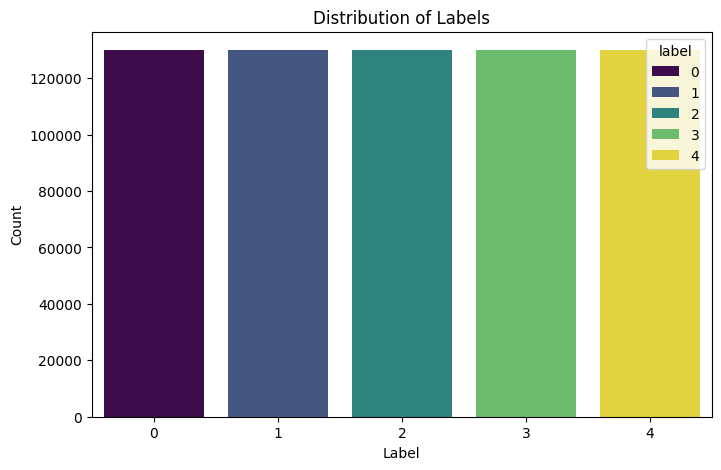

In [ ]:
#@title  Distribución de Ratings Originales
#@markdown Visualizamos cómo se distribuyen las calificaciones de 1 a 5 estrellas.

plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, hue='label', palette='viridis')
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


#### **Análisis de Variables Numéricas Asimétricas**
Calculamos la longitud del texto y el conteo de palabras para identificar posibles patrones en la extensión de las reseñas.



In [ ]:

#@title #### Estadisticas sobre los caracteres y las palabras en el dataset

# 2. Add text length columns for analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("Summary Statistics for Text Length:")
display(df[['text_length', 'word_count']].describe())


Summary Statistics for Text Length:


,text_length,word_count
count,650000.000000,650000.000000
mean,732.325468,134.098089
std,663.721184,121.396115
min,1.000000,1.000000
25%,287.000000,52.000000
50%,539.000000,99.000000
75%,957.000000,175.000000
max,5637.000000,1052.000000


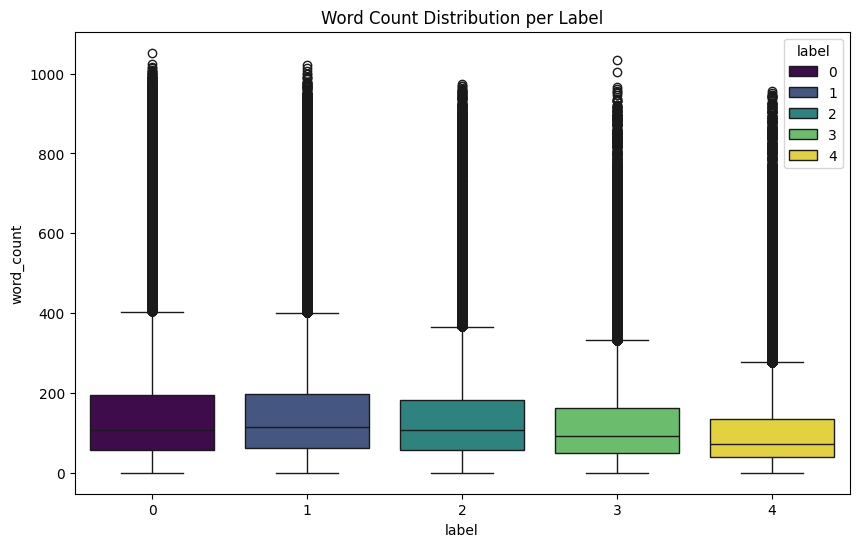

In [ ]:

#@title #### Average Word Count per Label
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='word_count', data=df, hue='label', palette='viridis')
plt.title('Word Count Distribution per Label')

plt.show()


##### Cantidad de mas larga y corta de palabras y letras

In [ ]:
#@title #### Texto con menos letra (una)
shortest_char_idx = df['text_length'].idxmin()
shortest_word_idx = df['word_count'].idxmin()

longest_char_idx = df['text_length'].idxmax()
longest_word_idx = df['word_count'].idxmax()

df.iloc[shortest_char_idx]

,1014
label,0
text,A
text_length,1
word_count,1


In [ ]:
#@title #### Texto con menos palabras (una)
df.iloc[shortest_word_idx]

,28
label,1
text,Hoofah.
text_length,7
word_count,1


In [ ]:
#@title #### Texto con mas letras
df.loc[longest_char_idx]

,614419
label,3
text,"Pour le jour de l'an 2010, nous \u00e9tions a ..."
text_length,5637
word_count,877


In [ ]:
#@title #### Texto con mas palabras
df.loc[longest_word_idx]


,241540
label,0
text,I made my appointment for a yearly PAP & seen ...
text_length,4978
word_count,1052


### **1.4 Análisis de Contenido y NLP**
- Word's Heat Map
- Procesamiento, normalización de datos
- Palabras dentro de cada estrella


---

In [ ]:

#@title Word's Heat Map

"""
Yelp Review NLP Pipeline
------------------------

Merges EDA + feature engineering into a single, clean script.
"""

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# ─────────────────────────────────────────────
# 2. EDA – BETTER WORD VISUALIZATION
#    TF-IDF heatmap: most *distinctive* words per rating
# ─────────────────────────────────────────────

def plot_tfidf_heatmap_improved(df, n_words=20, sample_per_label=5000, random_state=42):
    """
    For each star rating, compute the mean TF-IDF score of the top N words.
    Visualises a heatmap so you can see which words distinguish each rating
    instead of just which words appear most often overall.
    Improved version with a light theme and readable colors.
    """
    rating_labels = {0: '★☆☆☆☆', 1: '★★☆☆☆', 2: '★★★☆☆', 3: '★★★★☆', 4: '★★★★★'}

    # Sample for speed (if df is large)
    sampled = (
        df.groupby('label', group_keys=False)
          .apply(lambda g: g.sample(min(sample_per_label, len(g)), random_state=random_state))
    )

    # TF-IDF over the whole sample to get a shared vocabulary
    # sublinear_tf=True scales tf with 1 + log(tf) for better robustness.
    tfidf = TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        ngram_range=(1, 2),
        sublinear_tf=True,
        min_df=5,
    )
    X = tfidf.fit_transform(sampled['text'].fillna(''))
    vocab = np.array(tfidf.get_feature_names_out())

    # Mean TF-IDF per label
    label_scores = {}
    for label in sorted(df['label'].unique()):
        mask = (sampled['label'] == label).values
        mean_scores = np.asarray(X[mask].mean(axis=0)).flatten()
        label_scores[label] = mean_scores

    scores_df = pd.DataFrame(label_scores, index=vocab)
    # Map the labels to the star emoji strings
    scores_df.columns = [rating_labels[c] for c in scores_df.columns]

    # Pick the top N words that have the highest *max* score across any rating
    top_words = scores_df.max(axis=1).nlargest(n_words).index
    # Sort the final DataFrame by the 5-star rating scores in descending order
    plot_df = scores_df.loc[top_words].sort_values(rating_labels[4], ascending=False)

    # ── Plot ──────────────────────────────────
    # Create the figure with a clear white background (default)
    fig, ax = plt.subplots(figsize=(11, 9))

    # 1. Clear color settings
    # We remove the fig.patch.set_facecolor and ax.set_facecolor calls.
    # Text and annotation color should be dark for readability on light cells.
    text_color = '#333333' # Charcoal grey

    # 2. Optimized colormap for non-negative scores (sequential)
    # 'YlGnBu' goes from light yellow to deep blue.
    cmap = 'YlGnBu'

    # 3. Use seaborn's heatmap with explicit dark annotations
    sns.heatmap(
        plot_df,
        ax=ax,
        cmap=cmap,
        linewidths=0.6,
        linecolor='#e0e0e0', # Subtle light grey grid lines
        annot=True,
        fmt='.3f',
        # Set annotation color to dark charcoal grey
        annot_kws={'size': 9, 'color': text_color},
        cbar_kws={'shrink': 0.7, 'label': 'Mean TF-IDF score'},
    )

    # 4. Final label and tick customization for readability
    ax.set_title(
        'Most Distinctive Words per Star Rating\n(mean TF-IDF — higher = more characteristic of that rating)',
        fontsize=14, fontweight='bold', color=text_color, pad=18,
    )
    ax.set_xlabel('Star Rating', fontsize=12, color=text_color, labelpad=10)
    ax.set_ylabel('Word / Bigram', fontsize=12, color=text_color, labelpad=10)

    # Tick color and size for better visual flow
    ax.tick_params(colors=text_color, labelsize=10)
    plt.setp(ax.get_xticklabels(), rotation=0)
    plt.setp(ax.get_yticklabels(), rotation=0)

    # Colorbar label and tick color
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(colors=text_color, labelsize=9)
    cbar.set_label('Mean TF-IDF score', color=text_color, fontsize=10)

    plt.tight_layout(pad=2.0)
    # Adjust output facecolor just in case, though the figure is now clear.
    plt.savefig('word_heatmap_improved.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("Saved improved plot → word_heatmap_improved.png")

# Assuming 'df' is defined. Call the improved function:
# plot_tfidf_heatmap_improved(df, n_words=20)

/tmp/ipykernel_43415/4004161969.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(sample_per_label, len(g)), random_state=random_state))


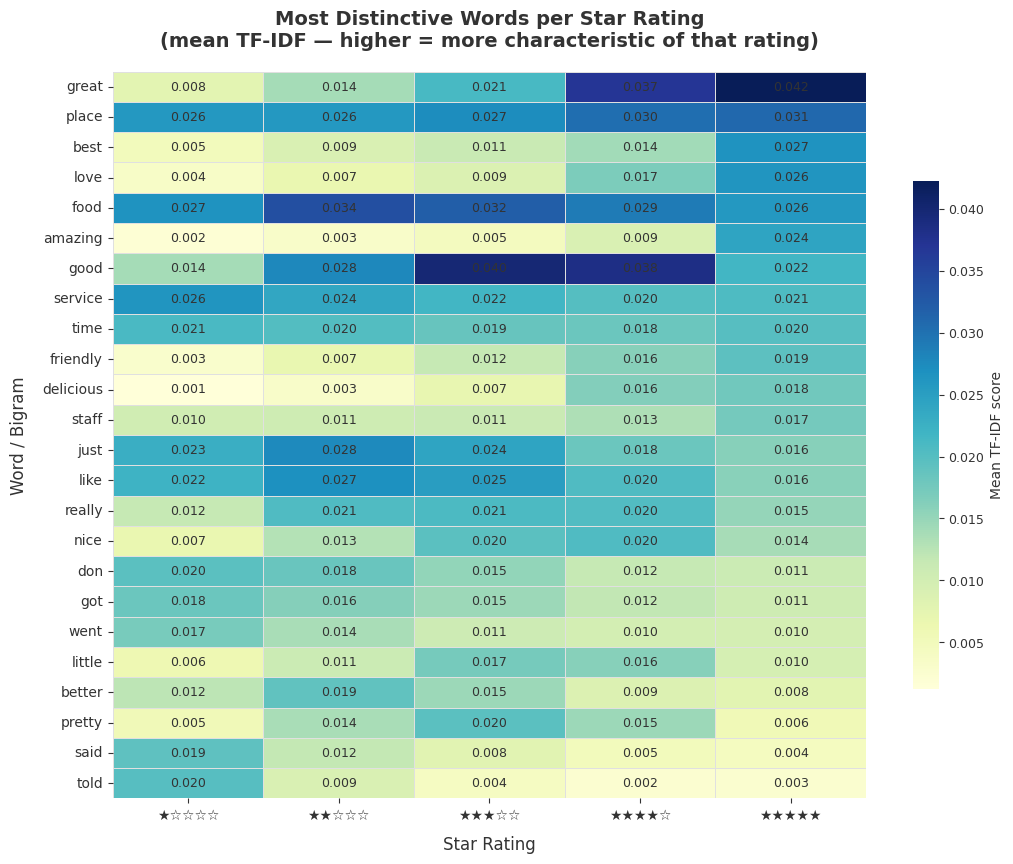

Saved improved plot → word_heatmap_improved.png


In [ ]:
plot_tfidf_heatmap_improved(df, n_words=24)

In [ ]:
#@title #### *Procesamiento*

# Tomamos una muestra para no sobrecargar memoria
df_sample = df.sample(n=50000, random_state=42)

# 1. Configuraciones de Memoria
MAX_FEATURES_WORD = 12000
MAX_FEATURES_CHAR = 12000
df_sample = df.sample(n=50000, random_state=42)


def preprocesar_word(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = texto.replace('\\n', ' ').replace('\\"', '"')
    texto = re.sub(r'http\S+', '', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


def preprocesar_char(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.replace('\\n', ' ').replace('\\"', '"')
    texto = texto.lower()
    texto = re.sub(r'http\S+', '', texto)
    return texto


print("Applying preprocessing…")
df_sample['text_word'] = df_sample['text'].apply(preprocesar_word)
df_sample['text_char'] = df_sample['text'].apply(preprocesar_char)

def extraer_features_extra(textos_originales):
    feats = {
        'exclamaciones':     textos_originales.apply(lambda x: min(x.count('!'), 10)),
        'mayusculas_ratio':  textos_originales.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)),
        'signos_pregunta':   textos_originales.apply(lambda x: min(x.count('?'), 5)),
        'word_count_log':    textos_originales.apply(lambda x: np.log1p(len(x.split()))),
    }
    return csr_matrix(pd.DataFrame(feats).values)

# Split
(X_train_word_text, X_test_word_text,
 X_train_char_text, X_test_char_text,
 X_train_orig,      X_test_orig,
 y_train,           y_test) = train_test_split(
    df_sample['text_word'],
    df_sample['text_char'],
    df_sample['text'],
    df_sample['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_sample['label'],
)


# Vectorización Dual (Palabras + Caracteres)
# ─────────────────────────────────────────────
# 7. VECTORISATION  (word TF-IDF + char TF-IDF + hand-crafted)
# ─────────────────────────────────────────────
tfidf_word = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 3),
    max_features=MAX_FEATURES_WORD,
    sublinear_tf=True, min_df=2, dtype=np.float32,
)

tfidf_char = TfidfVectorizer(
    analyzer='char', ngram_range=(3, 5),
    max_features=MAX_FEATURES_CHAR,
    sublinear_tf=True, min_df=8, dtype=np.float32,
)

print("Vectorising…")
X_train_word = tfidf_word.fit_transform(X_train_word_text)
X_test_word  = tfidf_word.transform(X_test_word_text)

X_train_char = tfidf_char.fit_transform(X_train_char_text)
X_test_char  = tfidf_char.transform(X_test_char_text)

print(f"  Word vocab : {len(tfidf_word.vocabulary_):,}")
print(f"  Char vocab : {len(tfidf_char.vocabulary_):,}")

X_train_extra = extraer_features_extra(X_train_orig)
X_test_extra  = extraer_features_extra(X_test_orig)

scaler        = MaxAbsScaler()
X_train_extra = scaler.fit_transform(X_train_extra)
X_test_extra  = scaler.transform(X_test_extra)

X_train_final = hstack([X_train_word, X_train_char, X_train_extra], format='csr')
X_test_final  = hstack([X_test_word,  X_test_char,  X_test_extra],  format='csr')

print(f"Final training shape : {X_train_final.shape}")

Applying preprocessing…
Vectorising…
  Word vocab : 12,000
  Char vocab : 12,000
Final training shape : (40000, 24004)


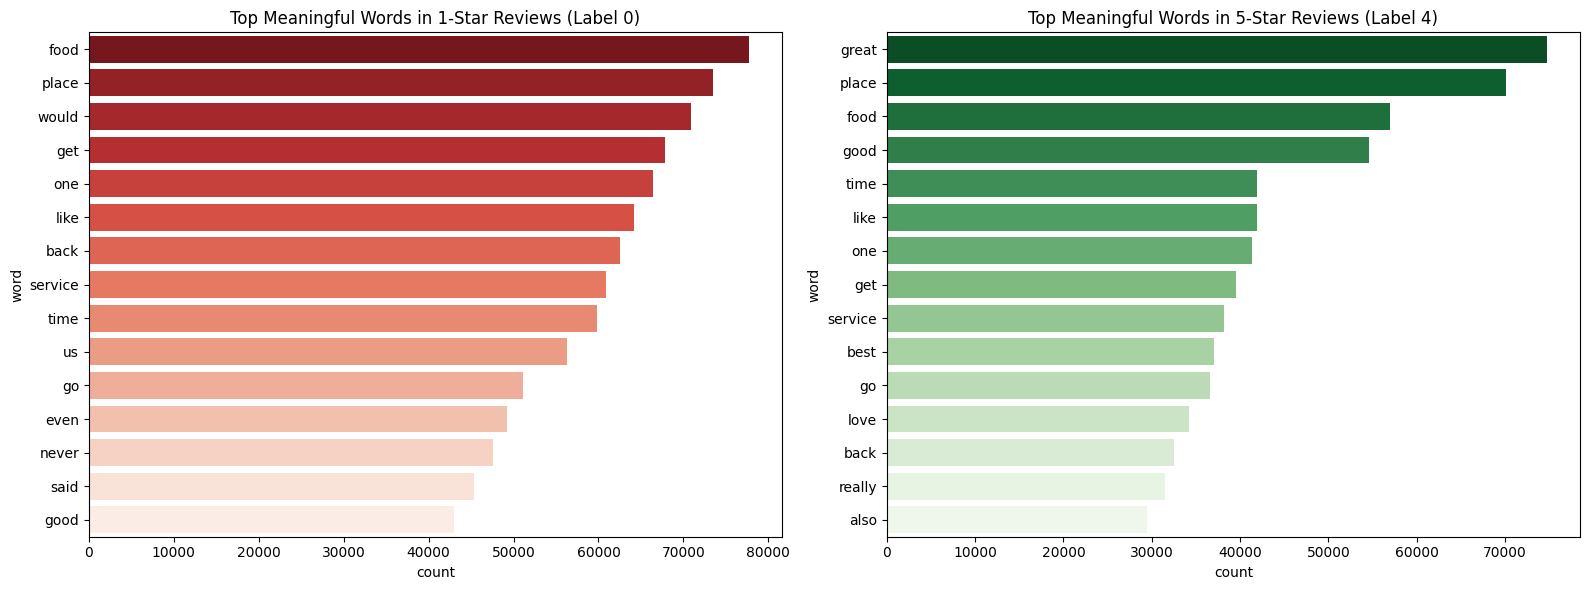

In [ ]:
#@title #### Palabras dentro de cada estrella

# Get top words for both classes

# Update the function to exclude stopwords
def get_top_n_words_filtered(corpus, n=None, n_gram=1):
    words = []
    for text in corpus:
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        # Filter out stopwords and very short tokens
        tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

        if n_gram > 1:
            tokens = [' '.join(tokens[i:i+n_gram]) for i in range(len(tokens)-n_gram+1)]
        words.extend(tokens)

    return Counter(words).most_common(n)
top_0 = get_top_n_words_filtered(df[df['label']==0]['text'], n=15)
top_4 = get_top_n_words_filtered(df[df['label']==4]['text'], n=15)

# Convert to DataFrames for easier plotting
df_0 = pd.DataFrame(top_0, columns=['word', 'count'])
df_4 = pd.DataFrame(top_4, columns=['word', 'count'])

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='count', y='word', data=df_0, ax=ax1, hue='word', palette='Reds_r', legend=False)
ax1.set_title('Top Meaningful Words in 1-Star Reviews (Label 0)')

sns.barplot(x='count', y='word', data=df_4, ax=ax2, hue='word', palette='Greens_r', legend=False)
ax2.set_title('Top Meaningful Words in 5-Star Reviews (Label 4)')

plt.tight_layout()
plt.show()


##  ***Segunda Parte*** (no ejecutar)
### *Entrenamiento supervisado*

---
---

### 2.1 **Preparacacion de metricas**

---

In [ ]:
#@title #### *Preparar metricas*

# ─────────────────────────────────────────────
# 8. HELPER FUNCTIONS
# ─────────────────────────────────────────────

TARGET_NAMES = ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars']


def especificidad_multiclase(y_true, y_pred):
    """Mean per-class specificity (TN / (TN + FP))."""
    cm = confusion_matrix(y_true, y_pred)
    especificidades = []
    for i in range(len(cm)):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        especificidades.append(TN / (TN + FP) if (TN + FP) > 0 else 0.0)
    return np.mean(especificidades)


def metricas_rapidas(y_true, y_pred):
    """Return a dict with the five core metrics."""
    return {
        "Accuracy"      : accuracy_score(y_true, y_pred),
        "F1-Score"      : f1_score(y_true, y_pred, average='weighted'),
        "Precision"     : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "Recall"        : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "Especificidad" : especificidad_multiclase(y_true, y_pred),
    }


def evaluar_modelo(nombre, y_true, y_pred):
    """Print full metrics report and plot confusion matrix."""
    print(f"\n{'─' * 64}")
    print(f"  MODELO: {nombre}")
    print(f"{'─' * 64}")

    m = metricas_rapidas(y_true, y_pred)
    print(f"  Exactitud      (Accuracy)    : {m['Accuracy']:.4f}")
    print(f"  Precisión      (Weighted)    : {m['Precision']:.4f}")
    print(f"  Sensibilidad   (Recall)      : {m['Recall']:.4f}")
    print(f"  F1-Score       (Weighted)    : {m['F1-Score']:.4f}")
    print(f"  Especificidad  (Specificity) : {m['Especificidad']:.4f}")
    print("\n  Reporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
    )
    plt.title(f'Matriz de Confusión: {nombre}')
    plt.xlabel('Predicho')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()


def graficar_ablation(df_ab, param_nombre, modelo_nombre):
    """Plot all five metrics vs. a hyperparameter for an ablation study."""
    metricas = ["Accuracy", "F1-Score", "Precision", "Recall", "Especificidad"]
    fig, axes = plt.subplots(1, len(metricas), figsize=(20, 4))
    for ax, metrica in zip(axes, metricas):
        ax.plot(df_ab[param_nombre], df_ab[metrica], marker='o', color='steelblue')
        ax.set_title(metrica)
        ax.set_xlabel(param_nombre)
        ax.set_ylabel("Score")
        ax.grid(True, linestyle='--', alpha=0.5)
        idx_best = df_ab[metrica].idxmax()
        ax.axvline(
            x=df_ab.loc[idx_best, param_nombre],
            color='red', linestyle=':', alpha=0.7,
            label=f"mejor={df_ab.loc[idx_best, param_nombre]}",
        )
        ax.legend(fontsize=8)
    fig.suptitle(f"Ablation Study — {modelo_nombre}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### **2.2Modelos de clacificación** (No ejecutar)
- Multinomial Naive Bayes (~7 segundos)
- Decision Tree (~48 minutos)
- Random Forest (~22 minutos)
- Support Vector Machine (SVM)(~9 minutos)
- Grafica Comparativa final

---

Ablation Study: Multinomial Naive Bayes (alpha)…
  alpha=0.01  | F1=0.5434 | 0.7s  ← mejor hasta ahora
  alpha=0.05  | F1=0.5434 | 0.7s  ← mejor hasta ahora
  alpha=0.1   | F1=0.5429 | 0.7s
  alpha=0.5   | F1=0.5419 | 0.7s
  alpha=1.0   | F1=0.5404 | 0.7s
  alpha=2.0   | F1=0.5372 | 0.9s

Resumen Ablation Multinomial Naive Bayes:



,alpha,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,2.00,0.91,0.5408,0.537204,0.537480,0.5408,0.885136
1,1.00,0.71,0.5434,0.540407,0.540441,0.5434,0.885787
2,0.50,0.72,0.5443,0.541855,0.541936,0.5443,0.886011
3,0.10,0.74,0.5447,0.542893,0.543257,0.5447,0.886108
4,0.05,0.67,0.5451,0.543414,0.543866,0.5451,0.886208
5,0.01,0.73,0.5449,0.543352,0.543908,0.5449,0.886157


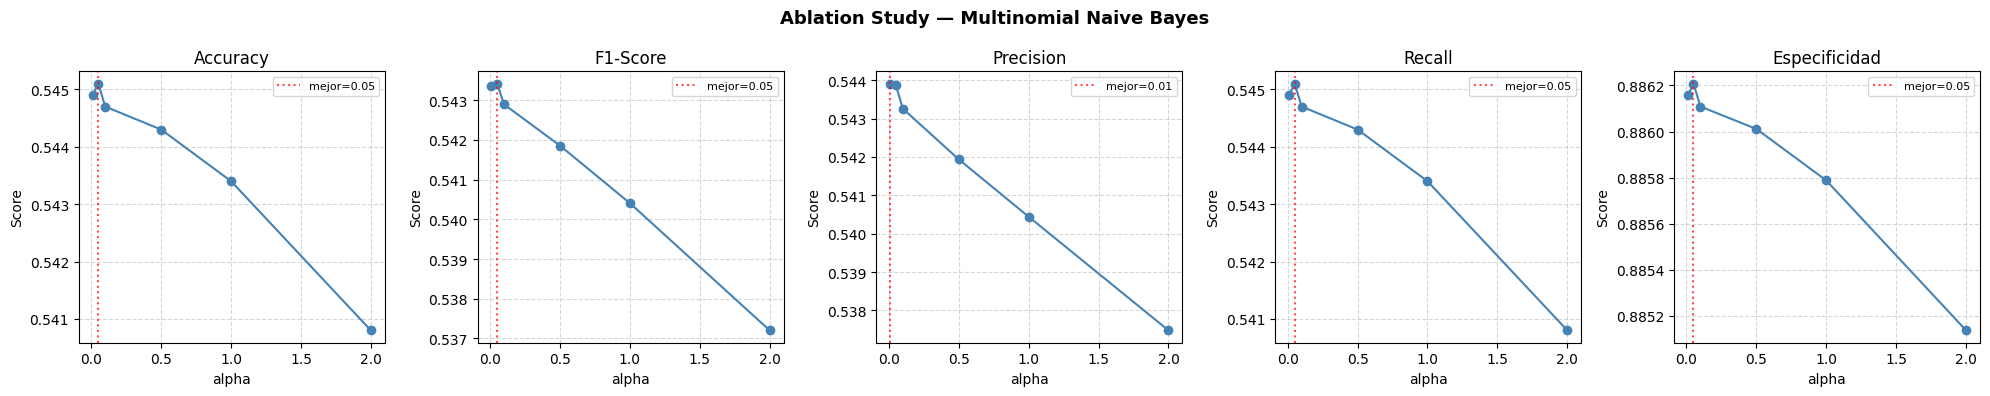


Mejor configuración: alpha=0.05
Entrenamiento final: 0.56s

────────────────────────────────────────────────────────────────
  MODELO: Multinomial Naive Bayes
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.5451
  Precisión      (Weighted)    : 0.5439
  Sensibilidad   (Recall)      : 0.5451
  F1-Score       (Weighted)    : 0.5434
  Especificidad  (Specificity) : 0.8862

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.62      0.70      0.66      2010
     2 Stars       0.47      0.42      0.45      1993
     3 Stars       0.47      0.48      0.47      2019
     4 Stars       0.50      0.51      0.50      2026
     5 Stars       0.66      0.61      0.64      1952

    accuracy                           0.55     10000
   macro avg       0.54      0.55      0.54     10000
weighted avg       0.54      0.55      0.54     10000



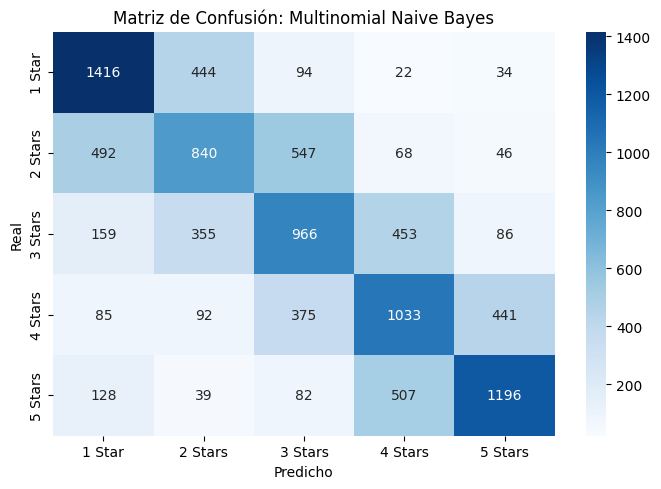

In [ ]:
#@title ###*1. Multinomial Naive Bayes*
print("Ablation Study: Multinomial Naive Bayes (alpha)…")
resultados_mnb = []
mejor_f1_mnb   = -1
mejor_alpha    = None

for alpha_val in [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]:
    t0 = time.time()
    mnb_ab = MultinomialNB(alpha=alpha_val)
    mnb_ab.fit(X_train_final, y_train)
    y_pred_val = mnb_ab.predict(X_test_final)
    elapsed = time.time() - t0

    row = {"alpha": alpha_val, "Tiempo(s)": round(elapsed, 2)}
    row.update(metricas_rapidas(y_test, y_pred_val))
    resultados_mnb.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_mnb:
        mejor_f1_mnb = row["F1-Score"]
        mejor_alpha  = alpha_val
        marca = "  ← mejor hasta ahora"

    print(f"  alpha={alpha_val:<5} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")

df_ablation_mnb = pd.DataFrame(resultados_mnb).sort_values("alpha", ascending=False).reset_index(drop=True)
print("\nResumen Ablation Multinomial Naive Bayes:\n")
display(df_ablation_mnb)
graficar_ablation(df_ablation_mnb, "alpha", "Multinomial Naive Bayes")

# Reentrenamiento final con mejor alpha
print(f"\nMejor configuración: alpha={mejor_alpha}")
t0 = time.time()
mejor_modelo_mnb = MultinomialNB(alpha=mejor_alpha)
mejor_modelo_mnb.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_mnb = mejor_modelo_mnb.predict(X_test_final)
evaluar_modelo("Multinomial Naive Bayes", y_test, y_pred_mnb)

Ablation Study: Decision Tree (max_depth)…
  max_depth=5   | F1=0.3422 | 71.9s  ← mejor hasta ahora
  max_depth=10  | F1=0.3652 | 203.7s  ← mejor hasta ahora
  max_depth=15  | F1=0.3763 | 356.1s  ← mejor hasta ahora
  max_depth=20  | F1=0.3680 | 536.8s
  max_depth=24  | F1=0.3579 | 613.1s
  max_depth=30  | F1=0.3531 | 728.0s

Resumen Ablation Decision Tree:



,max_depth,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,30,727.99,0.3517,0.353097,0.355714,0.3517,0.837875
1,24,613.08,0.3557,0.357917,0.362581,0.3557,0.838867
2,20,536.77,0.3662,0.367983,0.370884,0.3662,0.841496
3,15,356.11,0.3759,0.376252,0.377031,0.3759,0.843925
4,10,203.69,0.3789,0.365204,0.371527,0.3789,0.844631
5,5,71.93,0.3381,0.342177,0.388518,0.3381,0.834515


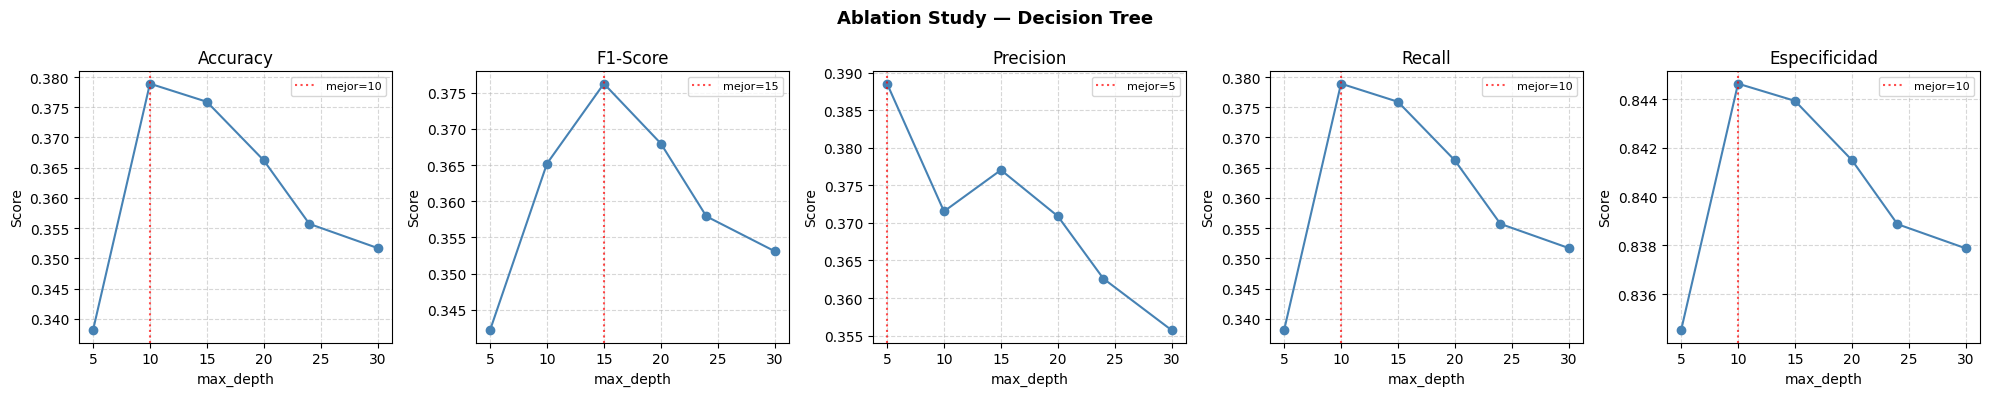


Mejor configuración: max_depth=15
Entrenamiento final: 365.32s

────────────────────────────────────────────────────────────────
  MODELO: Decision Tree
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.3759
  Precisión      (Weighted)    : 0.3770
  Sensibilidad   (Recall)      : 0.3759
  F1-Score       (Weighted)    : 0.3763
  Especificidad  (Specificity) : 0.8439

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.48      0.49      0.48      2010
     2 Stars       0.30      0.30      0.30      1993
     3 Stars       0.32      0.32      0.32      2019
     4 Stars       0.34      0.36      0.35      2026
     5 Stars       0.45      0.41      0.43      1952

    accuracy                           0.38     10000
   macro avg       0.38      0.38      0.38     10000
weighted avg       0.38      0.38      0.38     10000



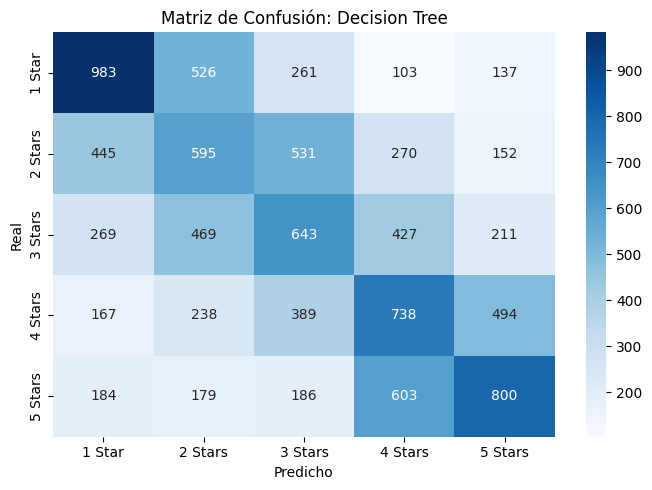

In [ ]:
#@title ### *2. Decision Tree*

print("Ablation Study: Decision Tree (max_depth)…")
resultados_dt  = []
mejor_f1_dt    = -1
mejor_depth    = None

for depth in [5, 10, 15, 20, 24, 30]:
    t0 = time.time()
    dt_ab = DecisionTreeClassifier(max_depth=depth, min_samples_split=12, random_state=42)
    dt_ab.fit(X_train_final, y_train)         # ← split principal
    y_pred_val = dt_ab.predict(X_test_final)  # ← test real
    elapsed = time.time() - t0

    row = {"max_depth": depth, "Tiempo(s)": round(elapsed, 2)}
    row.update(metricas_rapidas(y_test, y_pred_val))  # ← y_test
    resultados_dt.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_dt:
        mejor_f1_dt = row["F1-Score"]
        mejor_depth = depth
        marca = "  ← mejor hasta ahora"

    print(f"  max_depth={depth:<3} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")

df_ablation_dt = pd.DataFrame(resultados_dt).sort_values("max_depth", ascending=False).reset_index(drop=True)
print("\nResumen Ablation Decision Tree:\n")
display(df_ablation_dt)
graficar_ablation(df_ablation_dt, "max_depth", "Decision Tree")

# Reentrenamiento final con mejor depth
print(f"\nMejor configuración: max_depth={mejor_depth}")
t0 = time.time()
mejor_modelo_dt = DecisionTreeClassifier(max_depth=mejor_depth, min_samples_split=12, random_state=42)
mejor_modelo_dt.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_dt = mejor_modelo_dt.predict(X_test_final)
evaluar_modelo("Decision Tree", y_test, y_pred_dt)

Ablation Study: Random Forest (n_estimators)…
  n_estimators=20   | F1=0.4381 | 47.3s  ← mejor hasta ahora
  n_estimators=50   | F1=0.4590 | 163.6s  ← mejor hasta ahora
  n_estimators=100  | F1=0.4725 | 300.2s  ← mejor hasta ahora
  n_estimators=144  | F1=0.4731 | 456.4s  ← mejor hasta ahora

Resumen Ablation Random Forest:



,n_estimators,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,144,456.43,0.4842,0.473067,0.472182,0.4842,0.871039
1,100,300.24,0.4836,0.472547,0.471549,0.4836,0.870888
2,50,163.64,0.4696,0.458968,0.456994,0.4696,0.867386
3,20,47.30,0.4468,0.438065,0.435425,0.4468,0.861686


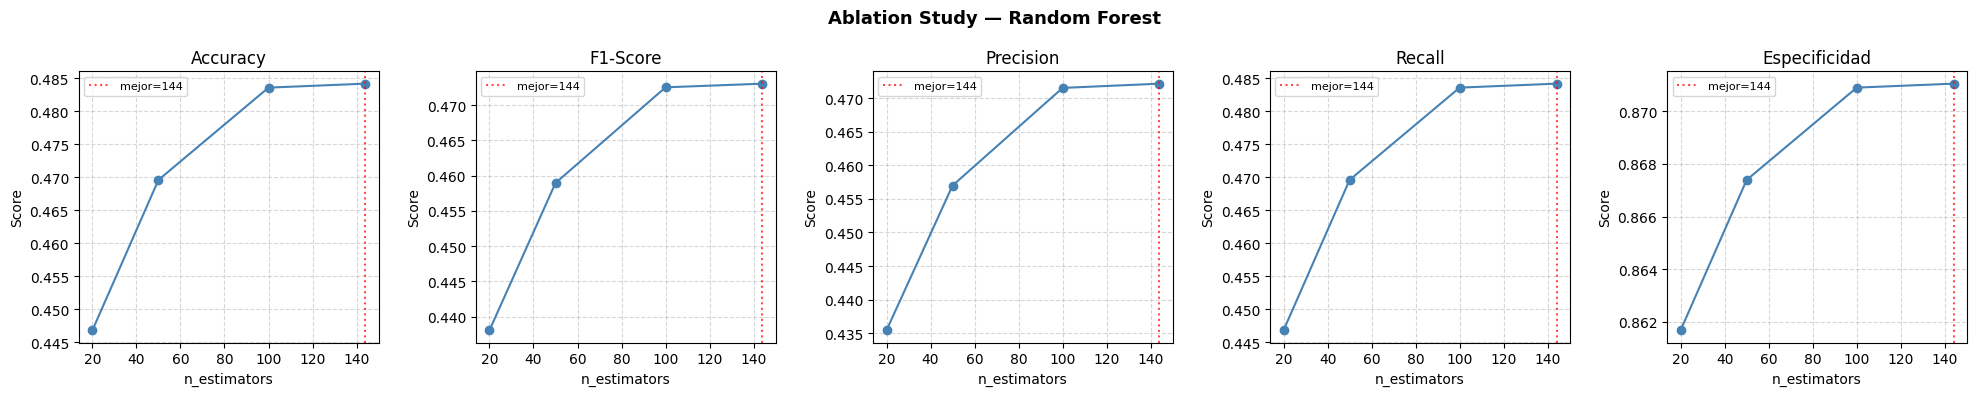


Mejor configuración: n_estimators=144
Entrenamiento final: 338.65s

────────────────────────────────────────────────────────────────
  MODELO: Random Forest
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.4842
  Precisión      (Weighted)    : 0.4722
  Sensibilidad   (Recall)      : 0.4842
  F1-Score       (Weighted)    : 0.4731
  Especificidad  (Specificity) : 0.8710

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.57      0.75      0.65      2010
     2 Stars       0.42      0.32      0.37      1993
     3 Stars       0.41      0.40      0.40      2019
     4 Stars       0.43      0.35      0.39      2026
     5 Stars       0.53      0.60      0.57      1952

    accuracy                           0.48     10000
   macro avg       0.47      0.48      0.47     10000
weighted avg       0.47      0.48      0.47     10000



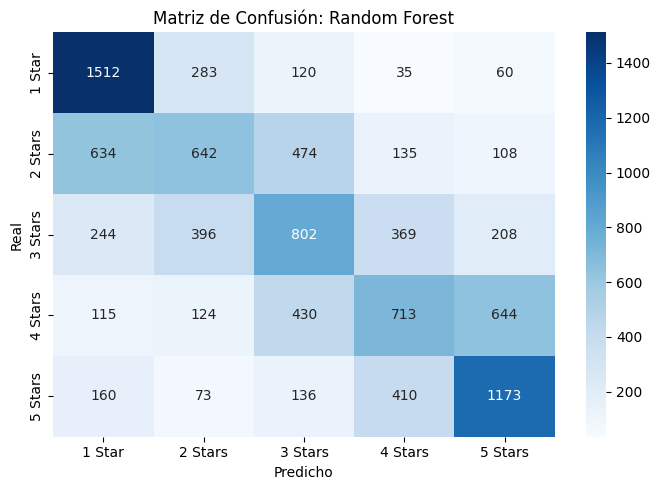

In [ ]:
#@title ### *3. Random Forest*

print("Ablation Study: Random Forest (n_estimators)…")
resultados_rf  = []
mejor_f1_rf    = -1
mejor_n_est    = None

for n_est in [20, 50, 100, 144]:
    t0 = time.time()
    rf_ab = RandomForestClassifier(n_estimators=n_est, max_depth=20, n_jobs=-1, random_state=42)
    rf_ab.fit(X_train_final, y_train)         # ← split principal
    y_pred_val = rf_ab.predict(X_test_final)  # ← test real
    elapsed = time.time() - t0

    row = {"n_estimators": n_est, "Tiempo(s)": round(elapsed, 2)}
    row.update(metricas_rapidas(y_test, y_pred_val))  # ← y_test
    resultados_rf.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_rf:
        mejor_f1_rf = row["F1-Score"]
        mejor_n_est = n_est
        marca = "  ← mejor hasta ahora"

    print(f"  n_estimators={n_est:<4} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")

df_ablation_rf = pd.DataFrame(resultados_rf).sort_values("n_estimators", ascending=False).reset_index(drop=True)
print("\nResumen Ablation Random Forest:\n")
display(df_ablation_rf)
graficar_ablation(df_ablation_rf, "n_estimators", "Random Forest")

# Reentrenamiento final con mejor n_estimators
print(f"\nMejor configuración: n_estimators={mejor_n_est}")
t0 = time.time()
mejor_modelo_rf = RandomForestClassifier(n_estimators=mejor_n_est, max_depth=20, n_jobs=-1, random_state=42)
mejor_modelo_rf.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_rf = mejor_modelo_rf.predict(X_test_final)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

Ablation Study: SVM (C)…
  C=0.01  | F1=0.5622 | 50.8s  ← mejor hasta ahora
  C=0.05  | F1=0.5800 | 70.3s  ← mejor hasta ahora
  C=0.1   | F1=0.5784 | 101.4s
  C=0.5   | F1=0.5572 | 121.5s
  C=1.0   | F1=0.5466 | 149.8s

Resumen Ablation SVM:



,C,Tiempo(s),Accuracy,F1-Score,Precision,Recall,Especificidad
0,1.00,149.77,0.5491,0.546610,0.545003,0.5491,0.887244
1,0.50,121.49,0.5605,0.557193,0.555319,0.5605,0.890097
2,0.10,101.41,0.5845,0.578389,0.576729,0.5845,0.896107
3,0.05,70.34,0.5873,0.579990,0.579025,0.5873,0.896812
4,0.01,50.78,0.5729,0.562159,0.564102,0.5729,0.893229


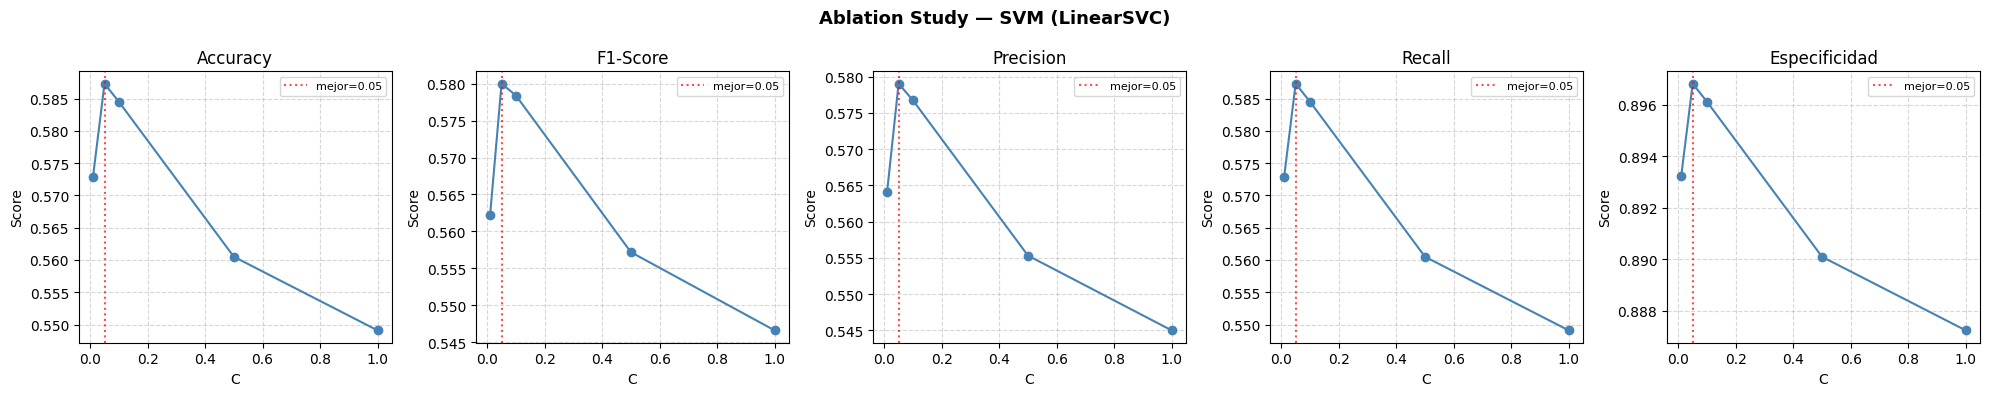


Mejor configuración: C=0.05
Entrenamiento final: 70.02s

────────────────────────────────────────────────────────────────
  MODELO: SVM (LinearSVC)
────────────────────────────────────────────────────────────────
  Exactitud      (Accuracy)    : 0.5873
  Precisión      (Weighted)    : 0.5790
  Sensibilidad   (Recall)      : 0.5873
  F1-Score       (Weighted)    : 0.5800
  Especificidad  (Specificity) : 0.8968

  Reporte de Clasificación:
              precision    recall  f1-score   support

      1 Star       0.67      0.80      0.73      2010
     2 Stars       0.55      0.46      0.50      1993
     3 Stars       0.52      0.49      0.51      2019
     4 Stars       0.52      0.45      0.49      2026
     5 Stars       0.64      0.73      0.68      1952

    accuracy                           0.59     10000
   macro avg       0.58      0.59      0.58     10000
weighted avg       0.58      0.59      0.58     10000



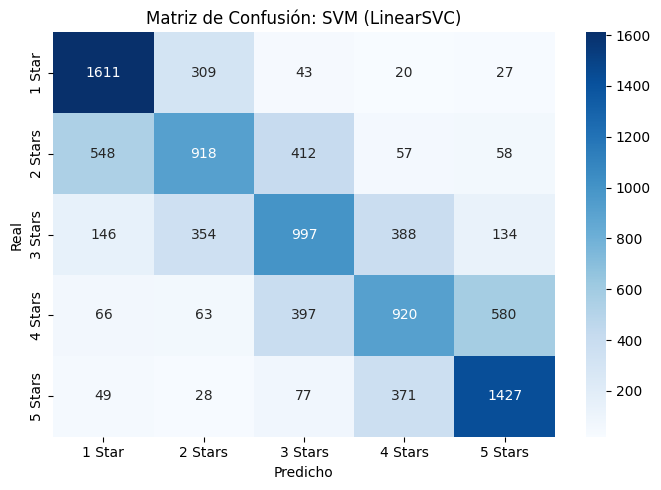

In [ ]:
#@title ### *4. Support Vector Machine (LinearSVC)*
print("Ablation Study: SVM (C)…")
resultados_svm = []
mejor_f1_svm   = -1
mejor_c        = None  # ← faltaba trackear el mejor C

for c_val in [0.01, 0.05, 0.1, 0.5, 1.0]:
    t0 = time.time()  # ← faltaba medir tiempo
    svm_ab = LinearSVC(C=c_val, max_iter=3000, random_state=42)
    svm_ab.fit(X_train_final, y_train)
    y_pred_val = svm_ab.predict(X_test_final)
    elapsed = time.time() - t0  # ← faltaba medir tiempo

    row = {"C": c_val, "Tiempo(s)": round(elapsed, 2)}  # ← faltaba Tiempo(s)
    row.update(metricas_rapidas(y_test, y_pred_val))
    resultados_svm.append(row)

    marca = ""
    if row["F1-Score"] > mejor_f1_svm:
        mejor_f1_svm = row["F1-Score"]
        mejor_c      = c_val  # ← faltaba guardar mejor C
        marca = "  ← mejor hasta ahora"

    print(f"  C={c_val:<5} | F1={row['F1-Score']:.4f} | {elapsed:.1f}s{marca}")  # ← faltaba print por iteración

df_ablation_svm = pd.DataFrame(resultados_svm).sort_values("C", ascending=False).reset_index(drop=True)  # ← faltaba sort y reset
print("\nResumen Ablation SVM:\n")
display(df_ablation_svm)  # ← faltaba display
graficar_ablation(df_ablation_svm, "C", "SVM (LinearSVC)")

# ← faltaba todo el bloque de reentrenamiento final
print(f"\nMejor configuración: C={mejor_c}")
t0 = time.time()
mejor_modelo_svm = LinearSVC(C=mejor_c, max_iter=3000, random_state=42)
mejor_modelo_svm.fit(X_train_final, y_train)
print(f"Entrenamiento final: {time.time() - t0:.2f}s")
y_pred_svm = mejor_modelo_svm.predict(X_test_final)
evaluar_modelo("SVM (LinearSVC)", y_test, y_pred_svm)

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Multinomial NB,0.5451,0.5439,0.5451,0.5434
Decision Tree,0.3759,0.3770,0.3759,0.3763
Random Forest,0.4842,0.4722,0.4842,0.4731
SVM,0.5873,0.5790,0.5873,0.5800


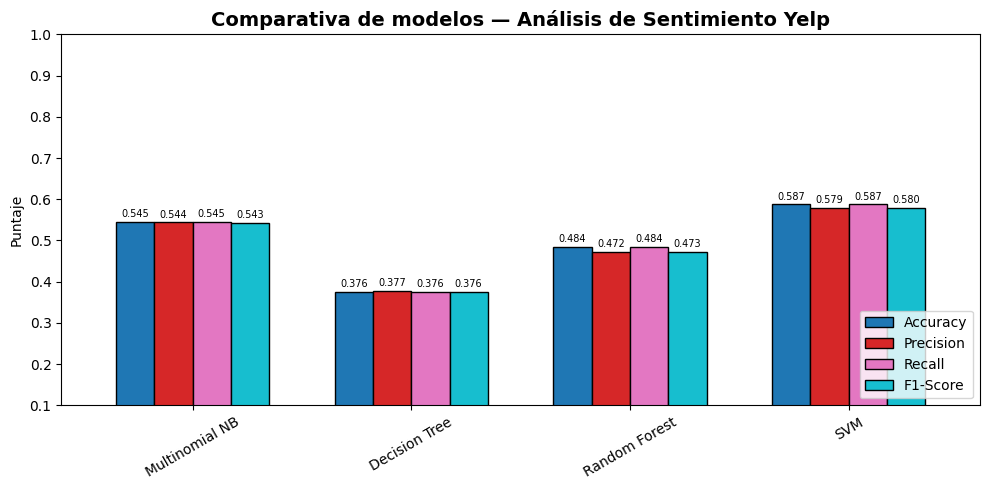

In [ ]:
#@title ### **Comparativa Final**

modelos_eval = []
if 'y_pred_mnb' in locals(): modelos_eval.append(("Multinomial NB", y_pred_mnb))
if 'y_pred_dt'  in locals(): modelos_eval.append(("Decision Tree",  y_pred_dt))
if 'y_pred_rf'  in locals(): modelos_eval.append(("Random Forest",  y_pred_rf))
if 'y_pred_svm' in locals(): modelos_eval.append(("SVM",            y_pred_svm))

resultados = {"Modelo": [], "Accuracy": [], "Precision": [], "Recall": [], "F1-Score": []}

for name, pred in modelos_eval:
    resultados["Modelo"].append(name)
    resultados["Accuracy"].append(accuracy_score(y_test, pred))
    resultados["Precision"].append(precision_score(y_test, pred, average='weighted', zero_division=0))
    resultados["Recall"].append(recall_score(y_test, pred, average='weighted', zero_division=0))
    resultados["F1-Score"].append(f1_score(y_test, pred, average='weighted', zero_division=0))

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
display(df_resultados.round(4))

# ─────────────────────────────────────────────
# Gráfico comparativo
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

df_resultados.plot(
    kind="bar",
    ax=ax,
    ylim=(0.1, 1.0),
    colormap="tab10",
    edgecolor="black",
    width=0.7,
)

ax.set_title("Comparativa de modelos — Análisis de Sentimiento Yelp", fontsize=14, fontweight="bold")
ax.set_ylabel("Puntaje")
ax.set_xlabel("")
ax.tick_params(axis='x', rotation=30)
ax.legend(loc="lower right")

# Etiquetas de valor encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)

plt.tight_layout()
plt.show()

---
---


##  ***Tercera Parte***
### *Entrenamiento por Deep Learning*

---
---

In [ ]:
# ============================================================
# DEEP LEARNING — IMPLEMENTACIÓN COMPLETA
# ============================================================


# ─── GENERADOR DE DATOS ──────────────────────────────────────
class SparseDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, y, batch_size=128, shuffle=True):
        super().__init__()
        self.X = X
        self.y = y.values if hasattr(y, 'values') else y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(self.X.shape[0])
        if self.shuffle: np.random.shuffle(self.indices)

    def __len__(self): return int(np.ceil(self.X.shape[0] / self.batch_size))

    def __getitem__(self, index):
        idx = self.indices[index * self.batch_size:(index + 1) * self.batch_size]
        return self.X[idx].toarray(), tf.keras.utils.to_categorical(self.y[idx], 5)

    def on_epoch_end(self):
        if self.shuffle: np.random.shuffle(self.indices)

train_gen = SparseDataGenerator(X_train_final, y_train, batch_size=128)
test_gen  = SparseDataGenerator(X_test_final,  y_test,  batch_size=128, shuffle=False)
input_dim = X_train_final.shape[1]

# ─── FUNCIÓN DE MÉTRICAS ─────────────────────────────────────
def get_full_metrics(model, gen, name):
    y_pred, y_true = [], []
    for i in range(len(gen)):
        bx, by = gen[i]
        y_pred.extend(np.argmax(model.predict(bx, verbose=0), axis=1))
        y_true.extend(np.argmax(by, axis=1))
    return {
        'Modelo':     name,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Precision':  precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':     recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1-Score':   f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }

def get_sklearn_metrics(model, X_test, y_test, name):
    X_dense = X_test.toarray() if hasattr(X_test, 'toarray') else X_test
    y_pred = model.predict(X_dense)
    return {
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-Score':  f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }

# ============================================================
# 1. ENTRENAMIENTO — ARQUITECTURA 1 (Base)
# ============================================================
print("▶ Entrenando Arquitectura 1 (DNN Base)...")
# Arquitectura simple: 2 capas ocultas, ReLU, Dropout, Adam lr=0.001
model1 = Sequential([
    Input(shape=(input_dim,)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])
model1.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])
h1 = model1.fit(train_gen, validation_data=test_gen, epochs=15, verbose=0)
print("  ✔ Arquitectura 1 lista.")

# ============================================================
# 2. ENTRENAMIENTO — ARQUITECTURA 2 (Regularizada + BN)
# ============================================================
print("▶ Entrenando Arquitectura 2 (DNN Regularizada + BatchNorm)...")
# Más capas, ELU, BatchNormalization, learning rate más bajo, RMSprop
model2 = Sequential([
    Input(shape=(input_dim,)),
    Dense(512, activation='elu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='elu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='elu'),
    Dropout(0.2),
    Dense(5, activation='softmax')
])
model2.compile(optimizer=RMSprop(0.0005), loss='categorical_crossentropy', metrics=['accuracy'])
h2 = model2.fit(train_gen, validation_data=test_gen, epochs=15, verbose=0)
print("  ✔ Arquitectura 2 lista.")

# ============================================================
# 3. CURVAS DE ENTRENAMIENTO (Loss y Accuracy)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Curvas de Entrenamiento — Arquitecturas DNN", fontsize=14, fontweight='bold')

epochs_range = range(1, len(h1.history['loss']) + 1)

# Arquitectura 1 — Loss
axes[0, 0].plot(epochs_range, h1.history['loss'],     label='Train Loss',      color='steelblue')
axes[0, 0].plot(epochs_range, h1.history['val_loss'], label='Val Loss',        color='steelblue', linestyle='--')
axes[0, 0].set_title("DNN Base — Pérdida (Loss)")
axes[0, 0].set_xlabel("Época"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Arquitectura 1 — Accuracy
axes[0, 1].plot(epochs_range, h1.history['accuracy'],     label='Train Accuracy', color='darkorange')
axes[0, 1].plot(epochs_range, h1.history['val_accuracy'], label='Val Accuracy',   color='darkorange', linestyle='--')
axes[0, 1].set_title("DNN Base — Accuracy")
axes[0, 1].set_xlabel("Época"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

epochs_range2 = range(1, len(h2.history['loss']) + 1)

# Arquitectura 2 — Loss
axes[1, 0].plot(epochs_range2, h2.history['loss'],     label='Train Loss',  color='seagreen')
axes[1, 0].plot(epochs_range2, h2.history['val_loss'], label='Val Loss',    color='seagreen', linestyle='--')
axes[1, 0].set_title("DNN Regularizada — Pérdida (Loss)")
axes[1, 0].set_xlabel("Época"); axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Arquitectura 2 — Accuracy
axes[1, 1].plot(epochs_range2, h2.history['accuracy'],     label='Train Accuracy', color='crimson')
axes[1, 1].plot(epochs_range2, h2.history['val_accuracy'], label='Val Accuracy',   color='crimson', linestyle='--')
axes[1, 1].set_title("DNN Regularizada — Accuracy")
axes[1, 1].set_xlabel("Época"); axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 4. ABLATION STUDY — Impacto de hiperparámetros
# ============================================================
print("\n▶ Ejecutando Ablation Study completo...")

ablation_results = []

# A) Número de neuronas (1 capa oculta)
for neurons in [64, 128, 256, 512]:
    m = Sequential([Input(shape=(input_dim,)), Dense(neurons, activation='relu'), Dense(5, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Neuronas={neurons}")
    r['Hiperparámetro'] = 'Cantidad de Neuronas'
    ablation_results.append(r)

# B) Número de capas ocultas
for n_layers in [1, 2, 3]:
    layers = [Input(shape=(input_dim,))]
    for _ in range(n_layers):
        layers_list = [Input(shape=(input_dim,))]
    capas = [Input(shape=(input_dim,))]
    # Construir dinámicamente
    m = Sequential()
    m.add(Input(shape=(input_dim,)))
    for _ in range(n_layers):
        m.add(Dense(128, activation='relu'))
    m.add(Dense(5, activation='softmax'))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Capas={n_layers}")
    r['Hiperparámetro'] = 'Número de Capas'
    ablation_results.append(r)

# C) Funciones de activación
for act in ['relu', 'elu', 'tanh']:
    m = Sequential([Input(shape=(input_dim,)), Dense(128, activation=act), Dense(64, activation=act), Dense(5, activation='softmax')])
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Activación={act}")
    r['Hiperparámetro'] = 'Función de Activación'
    ablation_results.append(r)

# D) Learning Rate y Optimizadores
for opt_name, opt in [('Adam lr=0.01', Adam(0.01)), ('Adam lr=0.001', Adam(0.001)),
                       ('SGD lr=0.01', SGD(0.01)), ('RMSprop', RMSprop(0.001))]:
    m = Sequential([Input(shape=(input_dim,)), Dense(128, activation='relu'), Dense(64, activation='relu'), Dense(5, activation='softmax')])
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(train_gen, epochs=5, verbose=0)
    r = get_full_metrics(m, test_gen, f"Opt={opt_name}")
    r['Hiperparámetro'] = 'Optimizador / LR'
    ablation_results.append(r)

df_ablation = pd.DataFrame(ablation_results)[['Hiperparámetro', 'Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]
print("\n─── RESULTADOS ABLATION STUDY ───────────────────────────")
display(df_ablation.round(4))

# Gráfica del ablation study
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Ablation Study — Impacto de Hiperparámetros (F1-Score)", fontsize=13, fontweight='bold')

grupos = ['Cantidad de Neuronas', 'Número de Capas', 'Función de Activación', 'Optimizador / LR']
colores = ['steelblue', 'darkorange', 'seagreen', 'crimson']

for ax, grupo, color in zip(axes.flat, grupos, colores):
    sub = df_ablation[df_ablation['Hiperparámetro'] == grupo]
    bars = ax.barh(sub['Modelo'], sub['F1-Score'], color=color, alpha=0.8)
    ax.set_xlim(sub['F1-Score'].min() * 0.97, sub['F1-Score'].max() * 1.02)
    ax.set_title(grupo)
    ax.set_xlabel("F1-Score")
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()



NameError: name 'tf' is not defined


##  ***Cuarto Parte***
### *Entrenamiento no supervisado*

---

► TruncatedSVD... varianza=0.791 | shape=(40000, 50)
► K-Means... dist=[21344  3697  7256  5383  2320]
► Agglomerative... dist=[173 167 217 753 190]
► DBSCAN buscando ~5 clusters...
  p=  10  eps=0.0704  clusters= 11  ruido=3836
  p=  12  eps=0.0718  clusters= 10  ruido=3695
  p=  14  eps=0.0729  clusters= 12  ruido=3532
  p=  15  eps=0.0739  clusters= 12  ruido=3416
  p=  17  eps=0.0748  clusters= 12  ruido=3305
  p=  19  eps=0.0758  clusters= 12  ruido=3168
  p=  21  eps=0.0769  clusters= 12  ruido=3060
  p=  23  eps=0.0778  clusters= 12  ruido=2961
  p=  25  eps=0.0785  clusters= 13  ruido=2875
  p=  26  eps=0.0796  clusters= 14  ruido=2763
  p=  28  eps=0.0804  clusters= 14  ruido=2686
  p=  30  eps=0.0814  clusters= 13  ruido=2582
  p=  32  eps=0.0822  clusters= 15  ruido=2484
  p=  34  eps=0.0832  clusters= 16  ruido=2400
  p=  35  eps=0.0841  clusters= 15  ruido=2310
  p=  37  eps=0.0850  clusters= 15  ruido=2219
  p=  39  eps=0.0858  clusters= 16  ruido=2137
  p=  41  eps=0.086

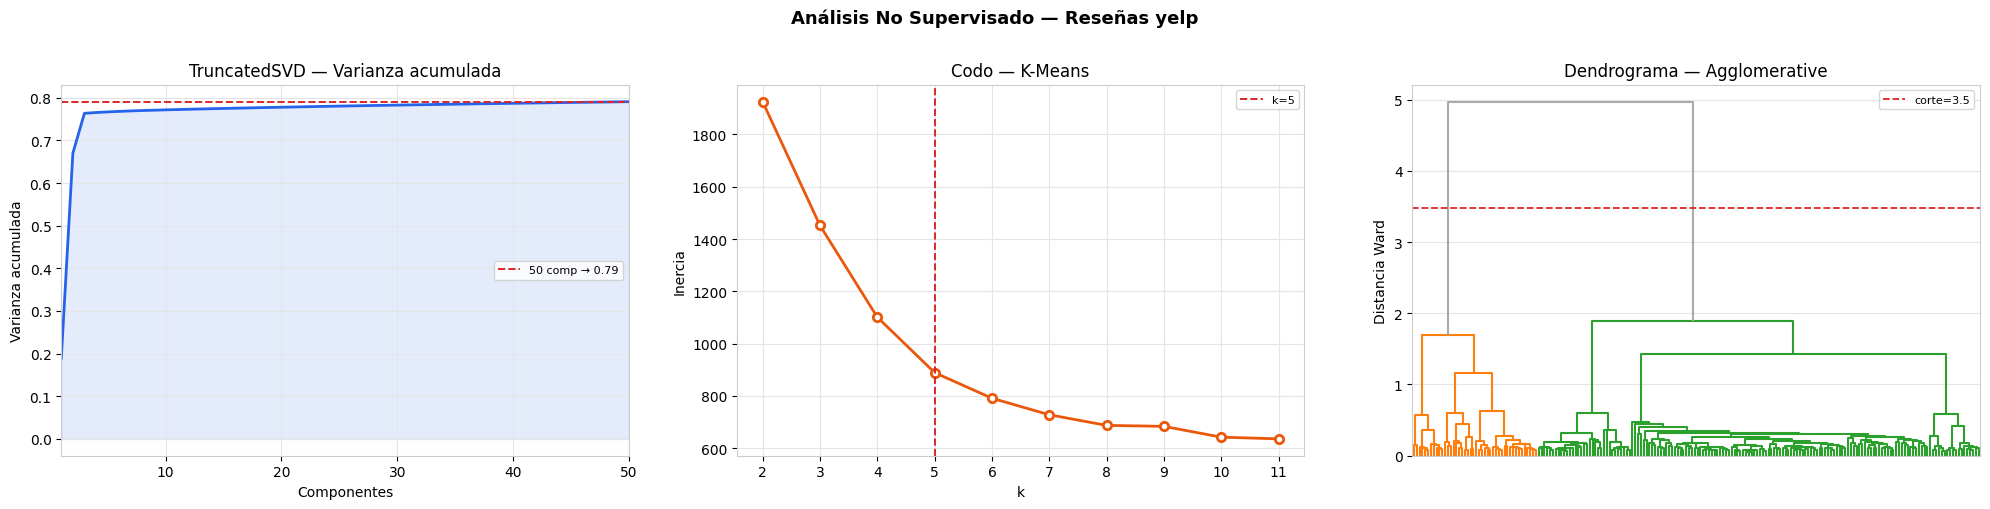

✓ fig1 guardada


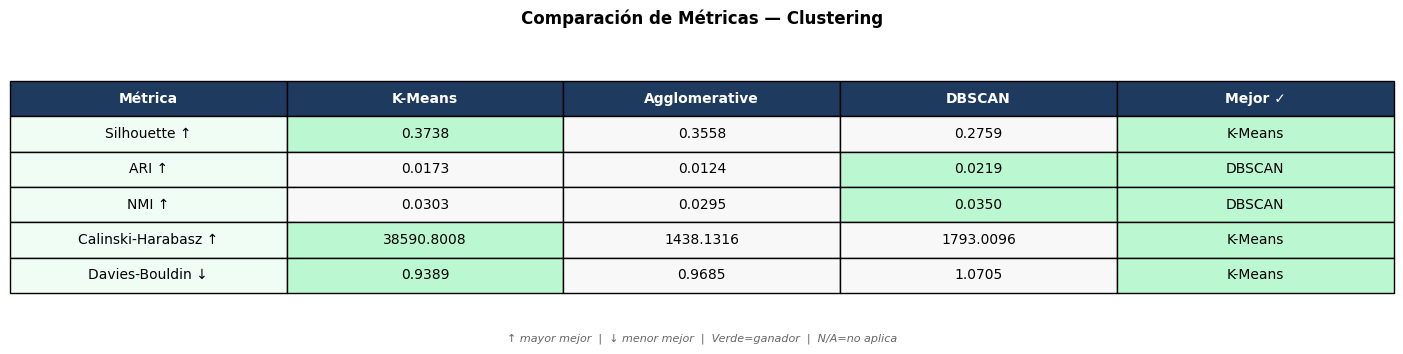

✓ fig2a_metricas_clustering.png guardada


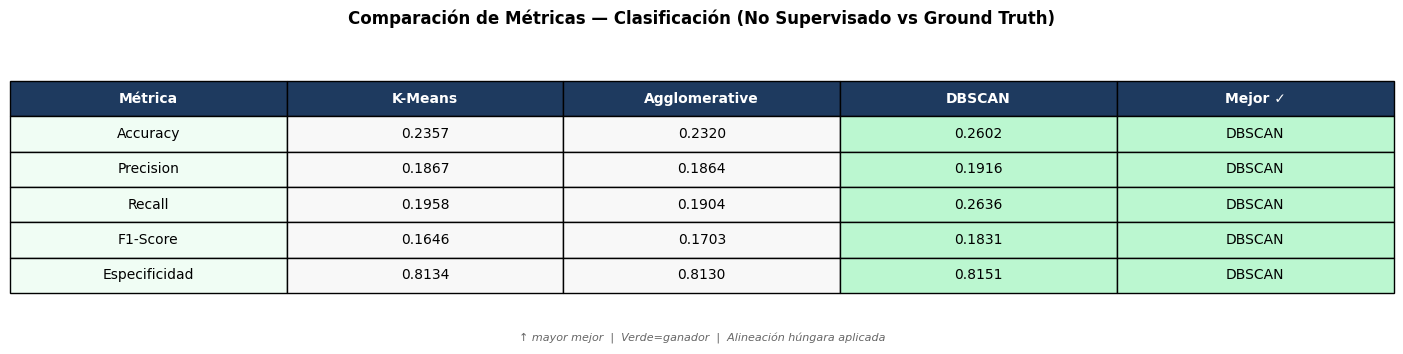

✓ fig2b_metricas_clasificacion.png guardada


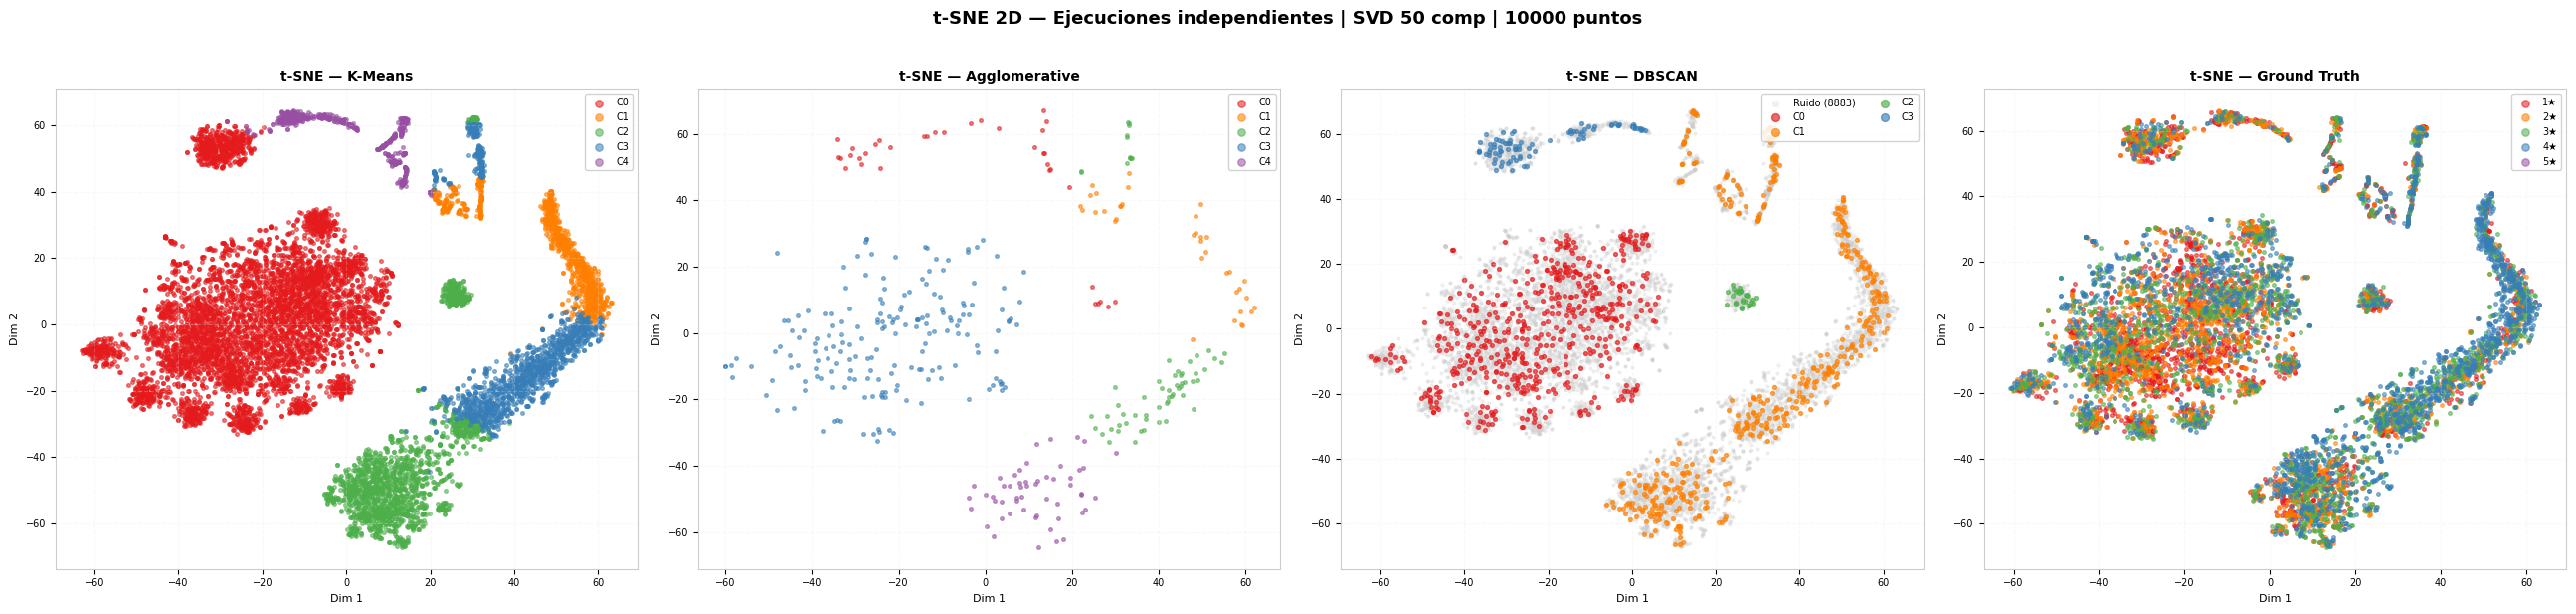

✓ fig3_tsne_2d guardada
► Preparando proyecciones... 10000 puntos
► t-SNE (1 ejecución sobre SVD reducido)... ✓


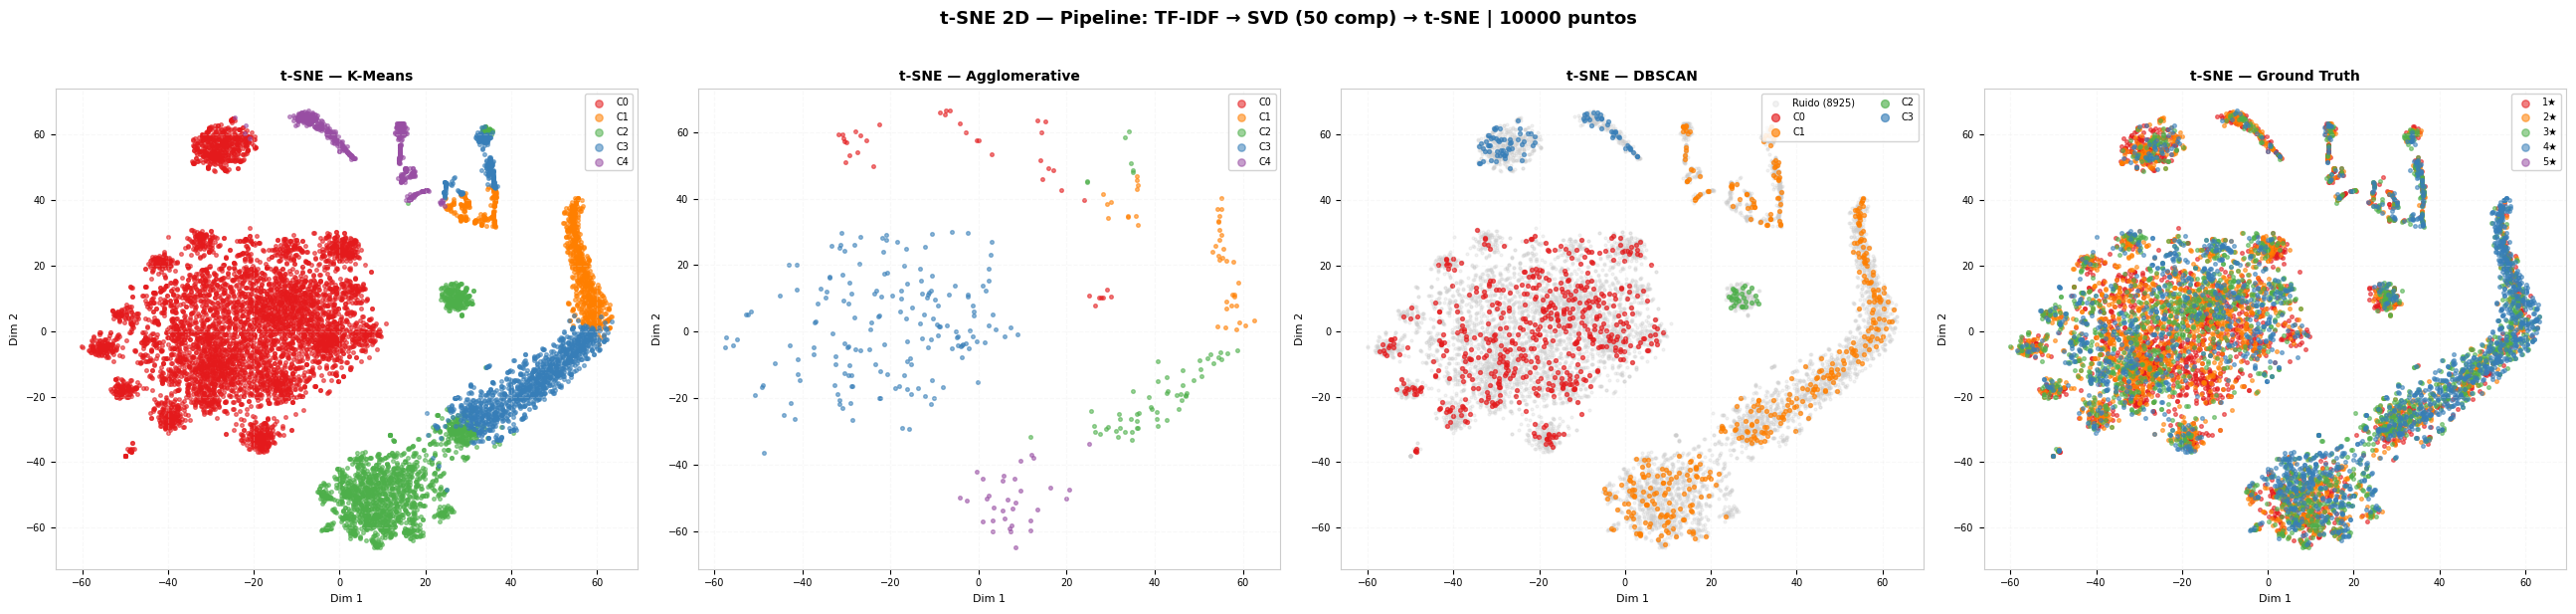

✓ fig3_tsne_2d guardada

✅ Todo listo. Figuras generadas:
  1. fig1_svd_codo_dendrograma.png
  2. fig2a_metricas_clustering.png
  3. fig2b_metricas_clasificacion.png
  4. fig3_tsne_2d.png
  5. fig7_distribucion_clusters.png
► t-SNE 3D (1 ejecución sobre SVD reducido)... 

NameError: name 'X_viz' is not defined

In [ ]:
  # ╔══════════════════════════════════════════════════════════════════════╗
  # ║   Modelos No Supervisados — Optimizado, sin repeticiones            ║
  # ║   TruncatedSVD · K-Means · Agglomerative · DBSCAN                  ║
  # ║   + Métricas clustering · Métricas clasificación · Visualizaciones  ║
  # ╚══════════════════════════════════════════════════════════════════════╝


  warnings.filterwarnings('ignore')

  # ══════════════════════════════════════════════════════════════
  # PARÁMETROS  ← ajusta según tu dataset
  # ══════════════════════════════════════════════════════════════
  N_SVD      = 50     # < min(n_muestras, n_features)
  N_CLUSTERS = 5
  N_VIZ      = 10000   # puntos para t-SNE / PCA 2D-3D  (↓ = menos RAM)
  N_AGG      = 1500   # submuestra Agglomerative
  N_DB       = 5000   # submuestra DBSCAN
  N_DEND     = 200    # submuestra dendrograma
  EPS        = None   # None → se calcula automático con k-dist
  MIN_PTS    = 10
  SEED       = 42

  # ── Paleta ────────────────────────────────────────────────────
  COLORES = ['#e41a1c', '#ff7f00', '#4daf4a', '#377eb8', '#984ea3']
  NOMBRES = ['1★', '2★', '3★', '4★', '5★']
  AZUL, ROJO, NARANJA, VERDE = '#2563eb', '#dc2626', '#ea580c', '#16a34a'
  COLOR_RUIDO = '#cccccc'

  plt.rcParams.update({
      'axes.facecolor':  'white', 'figure.facecolor': 'white',
      'axes.edgecolor':  '#ccc',  'grid.color':        '#e5e5e5',
      'grid.linewidth':  0.8,     'font.family':       'DejaVu Sans',
  })

  rng = np.random.default_rng(SEED)


  # ══════════════════════════════════════════════════════════════
  # UTILIDADES (sin repetición de código)
  # ══════════════════════════════════════════════════════════════

  def subsample(X, y, n):
      """Devuelve índices y submatrices aleatorias de tamaño n."""
      idx = rng.choice(len(X), min(n, len(X)), replace=False)
      return idx, X[idx], y[idx]



  def hungarian_align(y_true, y_pred):
      """
      Alinea etiquetas de clusters con clases reales mediante el algoritmo húngaro.
      Devuelve (y_pred_alineado, mask_no_ruido).
      """
      mask = y_pred != -1
      yt, yp = y_true[mask], y_pred[mask]
      D = max(yt.max() + 1, yp.max() + 1)
      cost = np.zeros((D, D), dtype=int)
      for i, j in zip(yt, yp):
          cost[i, j] += 1
      row, col = linear_sum_assignment(-cost)
      mapping = {c: r for r, c in zip(row, col)}
      y_aligned = y_pred.copy().astype(int)
      y_aligned[mask] = np.array([mapping.get(int(p), -1) for p in yp])
      return y_aligned, mask


  def metricas_clustering(X, y_true, y_pred):
      """Silhouette, ARI, NMI, Calinski-Harabasz, Davies-Bouldin."""
      mask = y_pred != -1
      Xf, yf, pf = X[mask], y_true[mask], y_pred[mask]
      ari = adjusted_rand_score(y_true, y_pred)
      nmi = normalized_mutual_info_score(y_true, y_pred)
      if len(np.unique(pf)) < 2:
          return dict(Silhouette=np.nan, ARI=ari, NMI=nmi, CH=np.nan, DB=np.nan)
      return dict(
          Silhouette=silhouette_score(Xf, pf),
          ARI=ari, NMI=nmi,
          CH=calinski_harabasz_score(Xf, pf),
          DB=davies_bouldin_score(Xf, pf),
      )


  def metricas_clasificacion(y_true, y_pred):
      """
      Accuracy, Precision, Recall, F1, Especificidad (macro).
      Usa alineación húngara internamente.
      """
      y_alin, mask = hungarian_align(y_true, y_pred)
      yt, yp = y_true[mask], y_alin[mask]
      labels_u = np.unique(yt)
      acc  = accuracy_score(yt, yp)
      prec = precision_score(yt, yp, average='macro', zero_division=0)
      rec  = recall_score(yt, yp, average='macro', zero_division=0)
      f1   = f1_score(yt, yp, average='macro', zero_division=0)
      cm   = confusion_matrix(yt, yp, labels=labels_u)
      espec = np.mean([
          (cm.sum() - cm[i].sum() - cm[:, i].sum() + cm[i, i]) /
          max((cm.sum() - cm[i].sum() - cm[:, i].sum() + cm[i, i]) +
              (cm[:, i].sum() - cm[i, i]), 1)
          for i in range(len(labels_u))
      ])
      return dict(Accuracy=acc, Precision=prec,
                  Recall=rec, F1_Score=f1, Especificidad=espec)


  def imprimir_tabla(df, titulo):
      print(f"\n{'═'*70}\n  {titulo}\n{'═'*70}")
      print(df.round(4).to_string())
      print('═'*70)


  def score_global(row):
      """Puntaje compuesto: Sil + ARI + NMI - DB (para elegir mejor modelo)."""
      return (
          (0 if np.isnan(row['Silhouette ↑']) else row['Silhouette ↑'])
          + row['ARI ↑'] + row['NMI ↑']
          - (0 if np.isnan(row['Davies-Bouldin ↓']) else row['Davies-Bouldin ↓'])
      )


  def scatter_panel(ax, X2d, labels, es_db=False, es_gt=False, titulo=''):
      """Dibuja un panel de scatter 2D (clusters o ground truth)."""
      ax.set_facecolor('white')
      if es_db:
          mask_r = labels == -1
          if mask_r.any():
              ax.scatter(X2d[mask_r, 0], X2d[mask_r, 1],
                        s=4, alpha=0.25, color=COLOR_RUIDO,
                        label=f'Ruido ({mask_r.sum()})')
          for i, cid in enumerate(np.unique(labels[labels != -1])):
              m = labels == cid
              ax.scatter(X2d[m, 0], X2d[m, 1], s=8, alpha=0.65,
                        color=COLORES[i % len(COLORES)], label=f'C{cid}')
          ax.legend(markerscale=2, fontsize=7, framealpha=0.85,
                    edgecolor='#ccc', loc='upper right', ncol=2)
      else:
          for c in range(N_CLUSTERS):
              m = labels == c
              ax.scatter(X2d[m, 0], X2d[m, 1], s=7, alpha=0.55,
                        color=COLORES[c],
                        label=NOMBRES[c] if es_gt else f'C{c}')
          ax.legend(markerscale=2, fontsize=7, framealpha=0.85,
                    edgecolor='#ccc', loc='upper right')
      ax.set_title(titulo, fontsize=10, fontweight='bold', pad=6)
      ax.set_xlabel('Dim 1', fontsize=8)
      ax.set_ylabel('Dim 2', fontsize=8)
      ax.tick_params(labelsize=7)
      ax.grid(True, linestyle='--', alpha=0.25)


  # ══════════════════════════════════════════════════════════════
  # 1. TruncatedSVD — reducción de dimensionalidad
  # ══════════════════════════════════════════════════════════════
  print("► TruncatedSVD...", end=' ')
  svd   = TruncatedSVD(n_components=N_SVD, random_state=SEED)
  X_svd = normalize(svd.fit_transform(X_train_final)).astype(np.float32)
  var_total = svd.explained_variance_ratio_.sum()
  print(f"varianza={var_total:.3f} | shape={X_svd.shape}")

  y_idx = y_train.values - 1   # etiquetas 0-based


  # ══════════════════════════════════════════════════════════════
  # 2. K-MEANS — curva del codo + modelo final
  # ══════════════════════════════════════════════════════════════
  print("► K-Means...", end=' ')
  ks       = list(range(2, 12))
  inertias = [MiniBatchKMeans(n_clusters=k, random_state=SEED, n_init=3)
              .fit(X_svd).inertia_ for k in ks]
  kmeans    = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=10)
  labels_km = kmeans.fit_predict(X_svd)
  print(f"dist={np.bincount(labels_km)}")


  # ══════════════════════════════════════════════════════════════
  # 3. AGGLOMERATIVE — submuestra  (O(n²) en memoria)
  # ══════════════════════════════════════════════════════════════
  print("► Agglomerative...", end=' ')
  idx_agg, X_agg, y_agg = subsample(X_svd, y_idx, N_AGG)
  labels_agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')\
              .fit_predict(X_agg)
  idx_dend   = rng.choice(len(X_agg), min(N_DEND, len(X_agg)), replace=False)
  print(f"dist={np.bincount(labels_agg)}")



# ══════════════════════════════════════════════════════════════
# 4. DBSCAN — submuestra, búsqueda de EPS para ~5 clusters
# ══════════════════════════════════════════════════════════════
  idx_db, X_db, y_db = subsample(X_svd, y_idx, N_DB)

  def buscar_eps(X_sub, min_pts, objetivo=5, pasos=50):
      nn = NearestNeighbors(n_neighbors=min_pts).fit(X_sub)
      dists, _ = nn.kneighbors(X_sub)
      k_dists = np.sort(dists[:, -1])

      mejor_eps, mejor_diff = None, np.inf
      for p in np.linspace(10, 99, pasos):
          eps = float(np.percentile(k_dists, p))
          labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X_sub)
          n_cls  = len(set(labels)) - (-1 in labels)
          diff   = abs(n_cls - objetivo)
          print(f"  p={p:4.0f}  eps={eps:.4f}  clusters={n_cls:3d}  "
                f"ruido={(labels==-1).sum():4d}")
          if diff < mejor_diff:
              mejor_diff, mejor_eps, mejor_labels = diff, eps, labels
          if n_cls == objetivo:           # encontrado exacto → para
              print(f"\n✓ Exacto: eps={eps:.4f} → {n_cls} clusters")
              return eps, labels
      print(f"\n⚠ Mejor aproximación: eps={mejor_eps:.4f} "
            f"→ {len(set(mejor_labels))-(-1 in mejor_labels)} clusters")
      return mejor_eps, mejor_labels

  print("► DBSCAN buscando ~5 clusters...")
  eps_val, labels_db = buscar_eps(X_db, MIN_PTS, objetivo=N_CLUSTERS)

  n_cls_db   = len(set(labels_db)) - (-1 in labels_db)
  n_noise_db = (labels_db == -1).sum()
  print(f"\nEPS={eps_val:.4f} | clústeres={n_cls_db} | "
        f"ruido={n_noise_db} ({100*n_noise_db/len(X_db):.1f}%)")


  # ══════════════════════════════════════════════════════════════
  # 5. MÉTRICAS CLUSTERING
  # ══════════════════════════════════════════════════════════════
  print("► Métricas clustering...")
  rows_clust = {
      'K-Means':        metricas_clustering(X_svd, y_idx,  labels_km),
      'Agglomerative':  metricas_clustering(X_agg, y_agg,  labels_agg),
      'DBSCAN':         metricas_clustering(X_db,  y_db,   labels_db),
  }
  df_clust = pd.DataFrame(rows_clust).T.rename(columns={
      'Silhouette': 'Silhouette ↑', 'ARI': 'ARI ↑', 'NMI': 'NMI ↑',
      'CH': 'Calinski-Harabasz ↑', 'DB': 'Davies-Bouldin ↓',
  })
  mejor = df_clust.apply(score_global, axis=1).idxmax()
  imprimir_tabla(df_clust, f'Métricas Clustering  |  Mejor: {mejor}')


  # ══════════════════════════════════════════════════════════════
  # 6. MÉTRICAS CLASIFICACIÓN (vs ground truth, alineación húngara)
  # ══════════════════════════════════════════════════════════════
  print("► Métricas clasificación...")
  rows_clf = {
      'K-Means':       metricas_clasificacion(y_idx, labels_km),
      'Agglomerative': metricas_clasificacion(y_agg, labels_agg),
      'DBSCAN':        metricas_clasificacion(y_db,  labels_db),
  }
  df_clf = pd.DataFrame(rows_clf).T.rename(columns={'F1_Score': 'F1-Score'})
  imprimir_tabla(df_clf, 'Métricas Clasificación — No Supervisado vs Ground Truth')


  # ══════════════════════════════════════════════════════════════
  # PROYECCIONES (una sola submuestra compartida para t-SNE / PCA)
  # ══════════════════════════════════════════════════════════════
  print("► Preparando proyecciones...", end=' ')
  idx_viz, X_viz, y_viz = subsample(X_svd, y_idx, N_VIZ)

  km_viz  = labels_km[idx_viz]
  agg_map = dict(zip(idx_agg, labels_agg))
  db_map  = dict(zip(idx_db,  labels_db))
  agg_viz = np.array([agg_map.get(i, -1) for i in idx_viz])
  db_viz  = np.array([db_map.get(i,  -1) for i in idx_viz])
  print(f"{len(idx_viz)} puntos")


  # ══════════════════════════════════════════════════════════════
  # t-SNE (4 ejecuciones independientes: km, agg, db, gt)
  # ══════════════════════════════════════════════════════════════
  print("► t-SNE (4 ejecuciones)...", end=' ')
  tsne_cfg = dict(n_components=2, perplexity=40, init='pca',
                  learning_rate='auto', n_iter=1000, n_jobs=-1)
  tsne_2d = {
      'km':  TSNE(**tsne_cfg, random_state=11).fit_transform(X_viz),
      'agg': TSNE(**tsne_cfg, random_state=22).fit_transform(X_viz),
      'db':  TSNE(**tsne_cfg, random_state=33).fit_transform(X_viz),
      'gt':  TSNE(**tsne_cfg, random_state=44).fit_transform(X_viz),
  }
  print("✓")


  # ══════════════════════════════════════════════════════════════
  # PCA 2D y 3D  (TruncatedSVD ya calculado → primeras componentes)
  # ══════════════════════════════════════════════════════════════
  # Las primeras 3 columnas de X_svd corresponden a las 3 componentes principales
  pca_2d = X_svd[idx_viz, :2]          # componentes 1 y 2
  pca_3d = X_svd[idx_viz, :3]          # componentes 1, 2 y 3
  var_12  = svd.explained_variance_ratio_[:2].sum()
  var_123 = svd.explained_variance_ratio_[:3].sum()
  print(f"PCA 2D varianza explicada: {var_12:.3f} | 3D: {var_123:.3f}")


  # ══════════════════════════════════════════════════════════════
  # FIG 1 — SVD varianza · Codo · Dendrograma
  # ══════════════════════════════════════════════════════════════
  fig, axes = plt.subplots(1, 3, figsize=(20, 5))

  # A — Varianza acumulada
  ax = axes[0]
  cum = np.cumsum(svd.explained_variance_ratio_)
  ax.fill_between(range(1, N_SVD + 1), cum, alpha=0.12, color=AZUL)
  ax.plot(range(1, N_SVD + 1), cum, color=AZUL, lw=2)
  ax.axhline(var_total, color=ROJO, ls='--', lw=1.4,
            label=f'{N_SVD} comp → {var_total:.2f}')
  ax.set(xlabel='Componentes', ylabel='Varianza acumulada',
        title='TruncatedSVD — Varianza acumulada', xlim=(1, N_SVD))
  ax.legend(fontsize=8); ax.grid(True)

  # B — Codo
  ax = axes[1]
  ax.plot(ks, inertias, 'o-', color=NARANJA, lw=2, ms=6, mfc='white', mew=2)
  ax.axvline(N_CLUSTERS, color=ROJO, ls='--', lw=1.4, label=f'k={N_CLUSTERS}')
  ax.set(xlabel='k', ylabel='Inercia', title='Codo — K-Means')
  ax.set_xticks(ks); ax.legend(fontsize=8); ax.grid(True)

  # C — Dendrograma
  ax = axes[2]
  lm = hierarchy.linkage(X_agg[idx_dend], method='ward')
  umbral = 0.7 * lm[:, 2].max()
  hierarchy.dendrogram(lm, ax=ax, no_labels=True,
                      color_threshold=umbral, above_threshold_color='#aaa')
  ax.axhline(umbral, color=ROJO, ls='--', lw=1.3, label=f'corte={umbral:.1f}')
  ax.set(ylabel='Distancia Ward', title='Dendrograma — Agglomerative')
  ax.legend(fontsize=8); ax.grid(True, axis='y')
  ax.tick_params(axis='x', bottom=False)

  fig.suptitle('Análisis No Supervisado — Reseñas yelp',
              fontsize=13, fontweight='bold', y=1.01)
  plt.tight_layout(w_pad=2.5)
  plt.savefig('fig1_svd_codo_dendrograma.png', dpi=150,
              bbox_inches='tight', facecolor='white')
  plt.show(); plt.close(fig)
  del lm; gc.collect()
  print("✓ fig1 guardada")


  # ══════════════════════════════════════════════════════════════
  # FIG 2 — Tabla visual de métricas CLUSTERING
  # ══════════════════════════════════════════════════════════════
  def tabla_visual(df, filas_cfg, titulo, pie, fname):
      fig, ax = plt.subplots(figsize=(14, 3.5))
      ax.axis('off'); fig.patch.set_facecolor('white')
      modelos = list(df.index)
      cols = ['Métrica'] + modelos + ['Mejor ✓']
      tdata, tcolors = [], []
      for col, mayor_mejor in filas_cfg:
          vals = {m: df.loc[m, col] for m in modelos}
          validos = {k: v for k, v in vals.items() if not np.isnan(v)}
          gan = (max(validos, key=validos.get) if mayor_mejor
                else min(validos, key=validos.get)) if validos else '—'
          fmt = lambda v: f'{v:.4f}' if not np.isnan(v) else 'N/A'
          row   = [col] + [fmt(vals[m]) for m in modelos] + [gan]
          color = ['#f0fdf4'] + \
                  ['#bbf7d0' if gan == m else '#f8f8f8' for m in modelos] + \
                  ['#bbf7d0']
          tdata.append(row); tcolors.append(color)
      tbl = ax.table(cellText=tdata, colLabels=cols, cellLoc='center',
                    loc='center', cellColours=tcolors)
      tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.0)
      for j in range(len(cols)):
          tbl[0, j].set_facecolor('#1e3a5f')
          tbl[0, j].set_text_props(color='white', fontweight='bold')
      ax.set_title(titulo, fontsize=12, fontweight='bold', pad=14)
      fig.text(0.5, 0.01, pie, ha='center', fontsize=8, color='#666', style='italic')
      plt.tight_layout()
      plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
      plt.show(); plt.close(fig)
      print(f"✓ {fname} guardada")

  tabla_visual(
      df_clust,
      [('Silhouette ↑', True), ('ARI ↑', True), ('NMI ↑', True),
      ('Calinski-Harabasz ↑', True), ('Davies-Bouldin ↓', False)],
      'Comparación de Métricas — Clustering',
      '↑ mayor mejor  |  ↓ menor mejor  |  Verde=ganador  |  N/A=no aplica',
      'fig2a_metricas_clustering.png',
  )

  tabla_visual(
      df_clf,
      [('Accuracy', True), ('Precision', True), ('Recall', True),
      ('F1-Score', True), ('Especificidad', True)],
      'Comparación de Métricas — Clasificación (No Supervisado vs Ground Truth)',
      '↑ mayor mejor  |  Verde=ganador  |  Alineación húngara aplicada',
      'fig2b_metricas_clasificacion.png',
  )


  # ══════════════════════════════════════════════════════════════
  # FIG 3 — t-SNE 2D  (4 paneles: KM · AGG · DB · GT)
  # ══════════════════════════════════════════════════════════════
  fig, axes = plt.subplots(1, 4, figsize=(26, 6))
  fig.patch.set_facecolor('white')

  paneles_tsne = [
      ('t-SNE — K-Means',        tsne_2d['km'],  km_viz,  False, False),
      ('t-SNE — Agglomerative',  tsne_2d['agg'], agg_viz, False, False),
      ('t-SNE — DBSCAN',         tsne_2d['db'],  db_viz,  True,  False),
      ('t-SNE — Ground Truth',   tsne_2d['gt'],  y_viz,   False, True),
  ]
  for ax, (titulo, X2d, lv, db_flag, gt_flag) in zip(axes, paneles_tsne):
      scatter_panel(ax, X2d, lv, es_db=db_flag, es_gt=gt_flag, titulo=titulo)

  fig.suptitle(f't-SNE 2D — Ejecuciones independientes | '
              f'SVD {N_SVD} comp | {len(idx_viz)} puntos',
              fontsize=13, fontweight='bold', y=1.02)
  plt.tight_layout()
  plt.savefig('fig3_tsne_2d.png', dpi=150, bbox_inches='tight', facecolor='white')
  plt.show(); plt.close(fig)
  print("✓ fig3_tsne_2d guardada")

  # ══════════════════════════════════════════════════════════════
  # PROYECCIONES — submuestra compartida
  # ══════════════════════════════════════════════════════════════
  print("► Preparando proyecciones...", end=' ')
  idx_viz, X_viz, y_viz = subsample(X_svd, y_idx, N_VIZ)

  km_viz  = labels_km[idx_viz]
  agg_map = dict(zip(idx_agg, labels_agg))
  db_map  = dict(zip(idx_db,  labels_db))
  agg_viz = np.array([agg_map.get(i, -1) for i in idx_viz])
  db_viz  = np.array([db_map.get(i,  -1) for i in idx_viz])
  print(f"{len(idx_viz)} puntos")


  # ══════════════════════════════════════════════════════════════
  # t-SNE — UNA sola ejecución sobre los N_SVD componentes SVD
  # (estándar: PCA/SVD primero → t-SNE sobre esas componentes)
  # ══════════════════════════════════════════════════════════════
  print("► t-SNE (1 ejecución sobre SVD reducido)...", end=' ')
  tsne_2d = TSNE(
      n_components=2, perplexity=40, init='pca',
      learning_rate='auto', n_iter=1000, n_jobs=-1,
      random_state=SEED
  ).fit_transform(X_viz)          # ← X_viz ya tiene N_SVD cols (50), no texto crudo
  print("✓")


  # ══════════════════════════════════════════════════════════════
  # FIG 3 — t-SNE 2D  (4 paneles con el MISMO embedding)
  # ══════════════════════════════════════════════════════════════
  fig, axes = plt.subplots(1, 4, figsize=(26, 6))
  fig.patch.set_facecolor('white')

  paneles_tsne = [
      ('t-SNE — K-Means',       km_viz,  False, False),
      ('t-SNE — Agglomerative', agg_viz, False, False),
      ('t-SNE — DBSCAN',        db_viz,  True,  False),
      ('t-SNE — Ground Truth',  y_viz,   False, True),
  ]
  for ax, (titulo, lv, db_flag, gt_flag) in zip(axes, paneles_tsne):
      scatter_panel(ax, tsne_2d, lv, es_db=db_flag, es_gt=gt_flag, titulo=titulo)

  fig.suptitle(
      f't-SNE 2D — Pipeline: TF-IDF → SVD ({N_SVD} comp) → t-SNE | {len(idx_viz)} puntos',
      fontsize=13, fontweight='bold', y=1.02
  )
  plt.tight_layout()
  plt.savefig('fig3_tsne_2d.png', dpi=150, bbox_inches='tight', facecolor='white')
  plt.show(); plt.close(fig)
  print("✓ fig3_tsne_2d guardada")


  # ══════════════════════════════════════════════════════════════
  # Limpieza final  (eliminadas fig4/5/6 — solo t-SNE)
  # ══════════════════════════════════════════════════════════════
  del X_viz, tsne_2d
  del km_viz, agg_viz, db_viz, y_viz, agg_map, db_map
  gc.collect()

  print("\n✅ Todo listo. Figuras generadas:")
  for i, f in enumerate([
      'fig1_svd_codo_dendrograma.png',
      'fig2a_metricas_clustering.png',
      'fig2b_metricas_clasificacion.png',
      'fig3_tsne_2d.png',
      'fig7_distribucion_clusters.png',
  ], 1):
      print(f"  {i}. {f}")

  # ══════════════════════════════════════════════════════════════
  # NUEVA SECCIÓN: t-SNE 3D (K-Means vs Ground Truth)
  # ══════════════════════════════════════════════════════════════
  print("► t-SNE 3D (1 ejecución sobre SVD reducido)...", end=' ')
  tsne_3d = TSNE(
      n_components=3, perplexity=40, init='pca',
      learning_rate='auto', n_iter=1000, n_jobs=-1,
      random_state=777
  ).fit_transform(X_viz)
  print("✓")

  def scatter_panel_3d(ax, X3d, labels, es_gt=False, titulo=''):
      """Dibuja un panel de scatter en 3D."""
      ax.set_facecolor('white')

      for c in range(N_CLUSTERS):
          m = labels == c
          ax.scatter(X3d[m, 0], X3d[m, 1], X3d[m, 2],
                    s=10, alpha=0.6,
                    color=COLORES[c % len(COLORES)],
                    label=NOMBRES[c] if es_gt else f'C{c}')

      ax.legend(markerscale=2, fontsize=8, framealpha=0.85,
                edgecolor='#ccc', loc='upper right')
      ax.set_title(titulo, fontsize=11, fontweight='bold', pad=10)
      ax.set_xlabel('Dim 1', fontsize=8)
      ax.set_ylabel('Dim 2', fontsize=8)
      ax.set_zlabel('Dim 3', fontsize=8)
      ax.tick_params(labelsize=7)

  # ══════════════════════════════════════════════════════════════
  # FIG 4 — t-SNE 3D (2 paneles: KM · GT)
  # ══════════════════════════════════════════════════════════════
  fig = plt.figure(figsize=(18, 8))
  fig.patch.set_facecolor('white')

  # Panel 1: K-Means
  ax1 = fig.add_subplot(121, projection='3d')
  scatter_panel_3d(ax1, tsne_3d, km_viz, es_gt=False, titulo='t-SNE 3D — K-Means')

  # Panel 2: Ground Truth
  ax2 = fig.add_subplot(122, projection='3d')
  scatter_panel_3d(ax2, tsne_3d, y_viz, es_gt=True, titulo='t-SNE 3D — Ground Truth')

  fig.suptitle(f't-SNE 3D — Pipeline: TF-IDF → SVD ({N_SVD} comp) → t-SNE | {len(idx_viz)} puntos',
              fontsize=14, fontweight='bold', y=0.98)

  plt.tight_layout()
  plt.savefig('fig4_tsne_3d.png', dpi=150, bbox_inches='tight', facecolor='white')
  plt.show()
  plt.close(fig)
  print("✓ fig4_tsne_3d guardada")

